<a href="https://colab.research.google.com/github/mnayebare/Amharic-Clip/blob/master/amharic_clip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda



Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Downloaded to: /root/.cache/huggingface/hub/models--michealnaye--AmharicCLIP/snapshots/207682c210cc58e92dbe513388d3bdf5c3c75e5a

Loading pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

  Done ✓
Generating: dog (EN) — 'a photo of a dog'


  0%|          | 0/50 [00:00<?, ?it/s]

  Done ✓
Generating: dog (AM) — 'ውሻ'


  0%|          | 0/50 [00:00<?, ?it/s]

  Done ✓


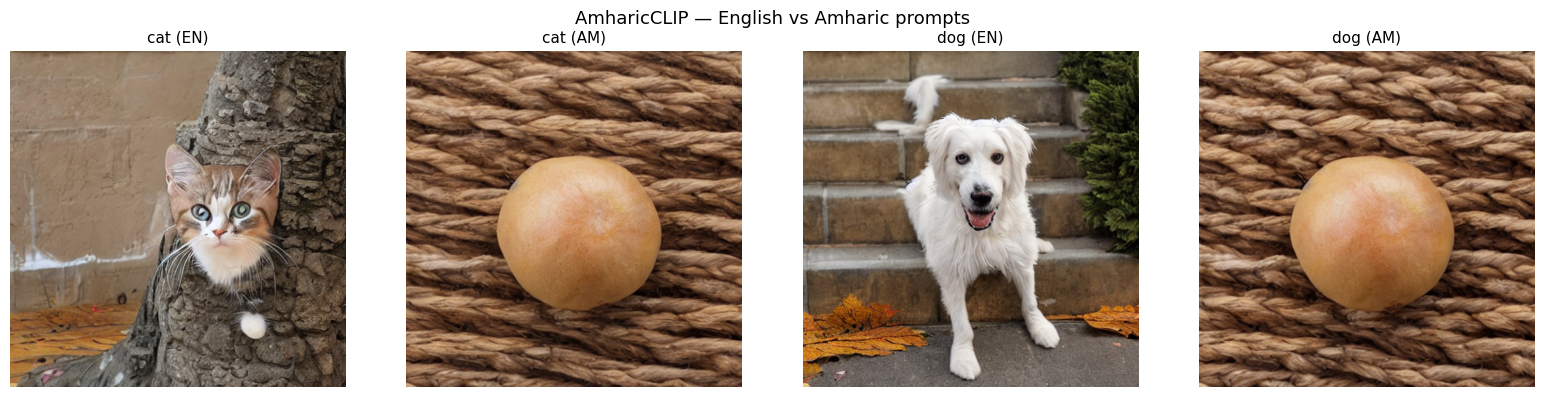


Saved: /content/cat_dog_comparison.png


In [ ]:
##
## this file tests model uploaded to hugging face
##
from diffusers import StableDiffusionPipeline
import torch
from PIL import Image
import matplotlib.pyplot as plt
from huggingface_hub import login, snapshot_download

login()

# Use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if device == "cuda" else torch.float32
print(f"Device: {device}\n")

if device == "cpu":
    print("WARNING: Running on CPU — generation will be very slow.")
    print("Go to Runtime → Change runtime type → Hardware accelerator → GPU\n")

# Download pipeline subfolder from HuggingFace
print("Downloading pipeline from HuggingFace...")
path = snapshot_download(
    repo_id="michealnaye/AmharicCLIP",
    allow_patterns="pipeline/*",
)
print(f"Downloaded to: {path}\n")

# Load pipeline
print("Loading pipeline...")
pipe = StableDiffusionPipeline.from_pretrained(
    f"{path}/pipeline",
    torch_dtype=dtype,
    safety_checker=None,
)
pipe = pipe.to(device)
print("Pipeline loaded ✓\n")

# Prompts
prompts = {
    "cat (EN)":  "photo of a cat",
    "cat (AM)":  "ድመት",
    "dog (EN)":  "a photo of a dog",
    "dog (AM)":  "ውሻ",
}

# Generate images
images = {}
for label, prompt in prompts.items():
    print(f"Generating: {label} — '{prompt}'")
    generator = torch.Generator(device=device).manual_seed(42)
    image = pipe(
        prompt,
        num_inference_steps=50,
        guidance_scale=7.5,
        generator=generator,
    ).images[0]
    images[label] = image
    print(f"  Done ✓")

# Display
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (label, image) in zip(axes, images.items()):
    ax.imshow(image)
    ax.set_title(label, fontsize=11)
    ax.axis("off")

plt.suptitle("AmharicCLIP — English vs Amharic prompts", fontsize=13)
plt.tight_layout()
plt.savefig("/content/cat_dog_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: /content/cat_dog_comparison.png")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading Stable Diffusion v1.5 baseline...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  Done ✓
Generating: dog (AM) — 'ውሻ'


  0%|          | 0/50 [00:00<?, ?it/s]

  Done ✓


FileNotFoundError: [Errno 2] No such file or directory: '/content/clip_amharic/baseline_cat_dog.png'

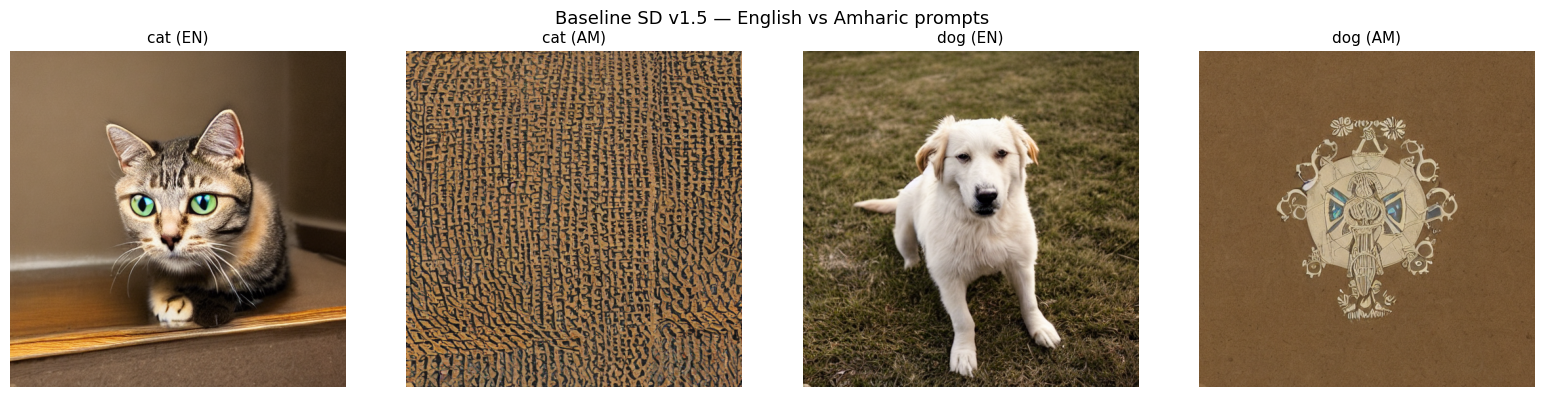

In [ ]:
##
## this script allows us to test the performance of the baseline stable diffussion
## it is not part of the main code work flow
##
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# Load default baseline SD v1.5
print("Loading Stable Diffusion v1.5 baseline...")
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None,
)
pipe = pipe.to("cuda")
print("Pipeline loaded ✓\n")

# Prompts — English and Amharic pairs
prompts = {
    "cat (EN)":  "a photo of a cat",
    "cat (AM)":  "ድመት",
    "dog (EN)":  "a photo of a dog",
    "dog (AM)":  "ውሻ",
}

# Generate images
images = {}
for label, prompt in prompts.items():
    print(f"Generating: {label} — '{prompt}'")
    generator = torch.Generator(device="cuda").manual_seed(42)
    image = pipe(
        prompt,
        num_inference_steps=50,
        guidance_scale=7.5,
        generator=generator,
    ).images[0]
    images[label] = image
    print(f"  Done ✓")

# Display side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (label, image) in zip(axes, images.items()):
    ax.imshow(image)
    ax.set_title(label, fontsize=11)
    ax.axis("off")

plt.suptitle("Baseline SD v1.5 — English vs Amharic prompts", fontsize=13)
plt.tight_layout()
plt.savefig("/content/clip_amharic/baseline_cat_dog.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: /content/clip_amharic/baseline_cat_dog.png")

In [ ]:
"""
##
## this is used when uploading data to hugging face and also when we received captions from the annotators
##
##
## Apply corrections to train/val/test JSON
## This file takes the human-verified Amharic captions from hf_metadata.csv
## and replaces the auto-generated captions in train.json, val.json, and test.json.
%run '/content/clip_amharic/apply_annotations.py'

# Retrain
%run '/content/clip_amharic/distillation_train.py'
%run '/content/clip_amharic/finetune_train.py
apply_annotations.py

Reads the completed annotation CSV from Amharic speakers and
updates train.json, val.json, test.json with human-verified captions.

Workflow:
    1. Annotators fill in caption_am in annotation_task.csv
    2. Run this script to apply corrections to the dataset
    3. Rerun finetune_train.py with the improved captions

Usage:
    python apply_annotations.py

Input:
    /content/clip_amharic/annotation_task.csv        (completed by annotators)
    /content/clip_amharic/annotation_task_summary.csv (optional — label-level)
    /content/dataset/train.json
    /content/dataset/val.json
    /content/dataset/test.json

Output:
    /content/dataset/train.json   (updated in place)
    /content/dataset/val.json     (updated in place)
    /content/dataset/test.json    (updated in place)
    /content/clip_amharic/annotation_report.json  (summary of changes)
"""

import json
import csv
from pathlib import Path
from collections import defaultdict

# =========================================================
# CONFIG
# =========================================================

# Primary source — hf_metadata.csv (contains image_url + corrected_am)
ANNOTATION_CSV  = Path("/content/clip_amharic/hf_metadata.csv")
# Fallback — annotation_task.csv if hf_metadata.csv not available
FALLBACK_CSV    = Path("/content/clip_amharic/annotation_task.csv")

DATASET_SPLITS  = [
    Path("/content/dataset/train.json"),
    Path("/content/dataset/val.json"),
    Path("/content/dataset/test.json"),
]

REPORT_PATH = Path("/content/clip_amharic/annotation_report.json")

# Minimum caption length to accept — reject empty or too short
MIN_CAPTION_LEN = 3

# =========================================================
# STEP 1: LOAD ANNOTATIONS
# =========================================================

print("Loading annotations...")

# Build two lookup maps:
# 1. image_path -> verified Amharic caption (from annotation_task.csv)
# 2. label -> verified Amharic caption (from annotation_task_summary.csv)

image_captions : dict[str, str] = {}   # image-level
label_captions : dict[str, str] = {}   # label-level fallback

# Load image-level annotations
# Use hf_metadata.csv if available, otherwise fall back to annotation_task.csv
csv_path = ANNOTATION_CSV if ANNOTATION_CSV.exists() else FALLBACK_CSV

if csv_path.exists():
    print(f"  Loading from: {csv_path.name}")
    with open(csv_path, encoding="utf-8") as f:
        reader = csv.DictReader(f)
        loaded = 0
        skipped = 0
        for row in reader:
            # hf_metadata.csv uses corrected_am column
            # annotation_task.csv also uses corrected_am
            # auto caption is in caption_am (hf_metadata) or auto_am (annotation_task)
            corrected = row.get("corrected_am", "").strip()
            auto_am   = row.get("caption_am", row.get("auto_am", "")).strip()
            image_path = row.get("image_path", "").strip()

            # Skip if annotator left corrected_am blank
            if not corrected or len(corrected) < MIN_CAPTION_LEN:
                skipped += 1
                continue

            # Skip if corrected_am is same as auto — annotator may not have reviewed
            # Still accept it — auto may have been correct
            if image_path:
                image_captions[image_path] = corrected
                loaded += 1

    print(f"  Annotations loaded : {loaded}")
    print(f"  Skipped (blank)    : {skipped}")

# Load label-level annotations (fallback for images not individually annotated)
if SUMMARY_CSV.exists():
    with open(SUMMARY_CSV, encoding="utf-8") as f:
        reader = csv.DictReader(f)
        loaded_labels = 0
        for row in reader:
            caption_am = row.get("caption_am", "").strip()
            label      = row.get("label", "").strip()
            if caption_am and len(caption_am) >= MIN_CAPTION_LEN and label:
                label_captions[label] = caption_am
                loaded_labels += 1

    print(f"  Label-level annotations: {loaded_labels} labels covered")

if not image_captions and not label_captions:
    print("\nERROR: No annotations found.")
    print("Make sure annotators have filled in the caption_am column")
    print(f"and saved the file to: {ANNOTATION_CSV}")
    exit(1)

print()

# =========================================================
# STEP 2: APPLY TO DATASET SPLITS
# =========================================================

report = {
    "image_level_updates": 0,
    "label_level_updates": 0,
    "unchanged":           0,
    "no_match":            0,
    "by_split":            {},
}

for split_path in DATASET_SPLITS:
    if not split_path.exists():
        print(f"  Skipping {split_path.name} — not found")
        continue

    with open(split_path, encoding="utf-8") as f:
        data = json.load(f)

    image_updates = 0
    label_updates = 0
    unchanged     = 0
    no_match      = 0

    for item in data:
        image_path = item.get("image_path", "")
        label      = item.get("label", "")
        old_am     = item.get("caption_am", "")

        # Priority 1: image-level annotation (most specific)
        if image_path in image_captions:
            new_am = image_captions[image_path]
            item["caption_am"] = new_am
            item["annotation_source"] = "human_image"
            if new_am != old_am:
                image_updates += 1
            else:
                unchanged += 1

        # Priority 2: label-level annotation (fallback)
        elif label in label_captions:
            new_am = label_captions[label]
            item["caption_am"] = new_am
            item["annotation_source"] = "human_label"
            if new_am != old_am:
                label_updates += 1
            else:
                unchanged += 1

        else:
            # No human annotation — keep auto-translation
            item["annotation_source"] = "auto"
            no_match += 1

    # Save updated split
    with open(split_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    total_updated = image_updates + label_updates
    print(f"  {split_path.name}:")
    print(f"    Image-level updates : {image_updates}")
    print(f"    Label-level updates : {label_updates}")
    print(f"    Already correct     : {unchanged}")
    print(f"    Auto-translation kept: {no_match}")
    print(f"    Total rows          : {len(data)}")
    print()

    report["image_level_updates"] += image_updates
    report["label_level_updates"] += label_updates
    report["unchanged"]           += unchanged
    report["no_match"]            += no_match
    report["by_split"][split_path.name] = {
        "image_updates": image_updates,
        "label_updates": label_updates,
        "unchanged":     unchanged,
        "no_match":      no_match,
        "total":         len(data),
    }

# =========================================================
# STEP 3: SAVE REPORT
# =========================================================

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

# =========================================================
# SUMMARY
# =========================================================

total_updates = report["image_level_updates"] + report["label_level_updates"]
total_rows    = sum(v["total"] for v in report["by_split"].values())
coverage      = total_updates / total_rows * 100 if total_rows > 0 else 0

print("=" * 55)
print("ANNOTATION APPLIED")
print("=" * 55)
print(f"Total rows updated   : {total_updates:,} / {total_rows:,} ({coverage:.1f}%)")
print(f"  Image-level        : {report['image_level_updates']:,}")
print(f"  Label-level        : {report['label_level_updates']:,}")
print(f"  Auto-translation   : {report['no_match']:,} (not annotated yet)")
print()
print(f"Report saved: {REPORT_PATH}")
print()
print("Next steps:")
print("  1. Review annotation_report.json")
print("  2. Rerun finetune_train.py with improved captions")
print("  3. Run amharic_sd_inference.py to see improvement")
print("=" * 55)

Logging in to HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


HfHubHTTPError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a1ba390-4dd4f16926e3234956cded0f;7c4f86ac-9567-407b-8514-1f59fd716574)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.

In [ ]:
  pip install transformers torch open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
"""
embedding_extension.py

Extends Stable Diffusion's CLIP text encoder (openai/clip-vit-large-patch14)
to support Amharic by adding one atomic token per Ethiopic character.

Before:
    CLIPTextModel embedding: [49408, 768]
    Amharic 'ድ' -> 3 byte fragments -> 3 separate lookups

After:
    CLIPTextModel embedding: [49920, 768]
    Amharic 'ድ' -> 1 atomic token -> 1 lookup

This model plugs directly into Stable Diffusion with no projection
needed since SD's text encoder already outputs 768-dim.

Usage:
    python embedding_extension.py

Output:
    /content/clip_amharic/
        extended_model/          <- HuggingFace format, loads with from_pretrained
        tokenizer_patch.json     <- Ethiopic char -> new token ID mapping
        extended_config.json     <- records what was changed

Install:
    pip install transformers torch open_clip_torch
"""

import json
import torch
import torch.nn as nn
from pathlib import Path
from datetime import datetime
from transformers import CLIPTextModel, CLIPTokenizer
from open_clip.tokenizer import SimpleTokenizer

# =========================================================
# CONFIG
# =========================================================

SD_MODEL_ID    = "openai/clip-vit-large-patch14"
OUTPUT_DIR     = Path("/content/clip_amharic")

ETHIOPIC_START = 0x1200
ETHIOPIC_END   = 0x1400   # exclusive — covers U+1200 to U+13FF

# =========================================================
# SETUP
# =========================================================

OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 55)
print("SD CLIP Text Encoder — Amharic Embedding Extension")
print("=" * 55)
print()

# =========================================================
# STEP 1: LOAD SD TEXT ENCODER
# =========================================================

print(f"[1/5] Loading SD text encoder ({SD_MODEL_ID})...")

text_encoder = CLIPTextModel.from_pretrained(SD_MODEL_ID)
tokenizer    = CLIPTokenizer.from_pretrained(SD_MODEL_ID)
text_encoder.eval()

# Handle different CLIPTextModel versions
if hasattr(text_encoder, 'text_model'):
    _emb_module = text_encoder.text_model.embeddings
elif hasattr(text_encoder, 'embeddings'):
    _emb_module = text_encoder.embeddings
else:
    raise AttributeError("Cannot find embedding module in CLIPTextModel")
orig_embedding  = _emb_module.token_embedding
orig_vocab_size, embed_dim = orig_embedding.weight.shape

print(f"  Original vocab size : {orig_vocab_size}")
print(f"  Embedding dimension : {embed_dim}")
print(f"  Weight dtype        : {orig_embedding.weight.dtype}")
print()

# =========================================================
# STEP 2: BUILD ETHIOPIC CHAR -> BYTE TOKEN ID MAPPING
# =========================================================

print("[2/5] Building Ethiopic character -> byte-fragment mapping...")

s = SimpleTokenizer()   # OpenCLIP tokenizer for byte mappings

char_to_new_id   : dict[str, int] = {}
char_to_byte_ids : dict[str, list] = {}

next_id      = orig_vocab_size   # 49408
skipped      = []

for cp in range(ETHIOPIC_START, ETHIOPIC_END):
    ch = chr(cp)
    try:
        utf8_bytes = ch.encode("utf-8")
        byte_token_ids = [
            s.encoder[s.byte_encoder[b]]
            for b in utf8_bytes
        ]
    except KeyError:
        skipped.append(ch)
        continue

    char_to_new_id[ch]   = next_id
    char_to_byte_ids[ch] = byte_token_ids
    next_id += 1

new_vocab_size = next_id
num_new_tokens = new_vocab_size - orig_vocab_size

print(f"  Ethiopic chars registered : {num_new_tokens}")
print(f"  Chars skipped             : {len(skipped)}")
print(f"  New vocab size            : {new_vocab_size}")
print()

# =========================================================
# STEP 3: INITIALIZE NEW EMBEDDING ROWS
# =========================================================

print("[3/5] Initializing new embedding rows from byte-fragment averages...")

orig_weight = orig_embedding.weight.data   # [49408, 768]
new_rows    = torch.zeros(
    num_new_tokens, embed_dim,
    dtype=orig_weight.dtype
)

for ch, new_id in char_to_new_id.items():
    byte_ids         = char_to_byte_ids[ch]
    row_idx          = new_id - orig_vocab_size
    byte_embeds      = orig_weight[byte_ids]       # [3, 768]
    new_rows[row_idx] = byte_embeds.mean(dim=0)    # [768]

avg_orig_norm = orig_weight.norm(dim=1).mean().item()
avg_new_norm  = new_rows.norm(dim=1).mean().item()
ratio         = avg_new_norm / avg_orig_norm

print(f"  Avg norm original tokens : {avg_orig_norm:.4f}")
print(f"  Avg norm new Ethiopic    : {avg_new_norm:.4f}")
print(f"  Norm ratio               : {ratio:.2f} "
      f"{'✓' if 0.3 < ratio < 3.0 else 'WARNING'}")
print()

# =========================================================
# STEP 4: EXTEND EMBEDDING MATRIX
# =========================================================

print("[4/5] Extending embedding matrix...")

extended_weight = torch.cat([orig_weight, new_rows], dim=0)

print(f"  Old shape : {orig_weight.shape}")
print(f"  New shape : {extended_weight.shape}")

# Replace embedding layer
_emb_module.token_embedding = nn.Embedding(
    new_vocab_size, embed_dim,
    dtype=orig_weight.dtype
)
_emb_module.token_embedding.weight.data = extended_weight

# Update config
text_encoder.config.vocab_size = new_vocab_size

assert _emb_module.token_embedding.weight.shape == \
    (new_vocab_size, embed_dim), "Shape mismatch"

print(f"  Extended successfully ✓\n")

# =========================================================
# STEP 5: SAVE
# =========================================================

print("[5/5] Saving outputs...")

# Save in HuggingFace format so it loads with from_pretrained
model_path = OUTPUT_DIR / "extended_model"
text_encoder.save_pretrained(str(model_path))
print(f"  Model saved : {model_path}")

# Save tokenizer patch
patch = {
    "description":         "Ethiopic char to SD CLIP token ID mapping",
    "base_model":          SD_MODEL_ID,
    "original_vocab_size": orig_vocab_size,
    "new_vocab_size":      new_vocab_size,
    "num_new_tokens":      num_new_tokens,
    "ethiopic_range":      f"U+{ETHIOPIC_START:04X} to U+{ETHIOPIC_END-1:04X}",
    "char_to_token_id":    {ch: tid for ch, tid in char_to_new_id.items()},
}
patch_path = OUTPUT_DIR / "tokenizer_patch.json"
with open(patch_path, "w", encoding="utf-8") as f:
    json.dump(patch, f, ensure_ascii=False, indent=2)
print(f"  Patch saved : {patch_path}")

# Save config
config = {
    "created_at":          datetime.now().isoformat(),
    "base_model":          SD_MODEL_ID,
    "original_vocab_size": orig_vocab_size,
    "new_vocab_size":      new_vocab_size,
    "embed_dim":           embed_dim,
    "num_new_tokens":      num_new_tokens,
    "initialization":      "byte_fragment_average",
    "avg_orig_norm":       round(avg_orig_norm, 6),
    "avg_new_norm":        round(avg_new_norm, 6),
    "norm_ratio":          round(ratio, 6),
    "next_steps": [
        "1. distillation_train.py  — align with XLM-R (no projection needed)",
        "2. finetune_train.py      — visual alignment on image-caption pairs",
        "3. amharic_sd_inference.py — plug into SD pipeline directly",
    ]
}
config_path = OUTPUT_DIR / "extended_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)
print(f"  Config saved: {config_path}")

print()
print("=" * 55)
print("EMBEDDING EXTENSION COMPLETE")
print("=" * 55)
print(f"Base model      : {SD_MODEL_ID}")
print(f"Original vocab  : {orig_vocab_size:,}")
print(f"New vocab       : {new_vocab_size:,}  (+{num_new_tokens} Ethiopic tokens)")
print(f"Embedding dim   : {embed_dim}  (matches SD UNet — no projection needed)")
print()
print("Output:")
print(f"  {model_path}/")
print(f"  {patch_path}")
print(f"  {config_path}")
print()
print("Next step: run distillation_train.py")
print("=" * 55)

SD CLIP Text Encoder — Amharic Embedding Extension

[1/5] Loading SD text encoder (openai/clip-vit-large-patch14)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  Original vocab size : 49408
  Embedding dimension : 768
  Weight dtype        : torch.float32

[2/5] Building Ethiopic character -> byte-fragment mapping...
  Ethiopic chars registered : 512
  Chars skipped             : 0
  New vocab size            : 49920

[3/5] Initializing new embedding rows from byte-fragment averages...
  Avg norm original tokens : 0.3854
  Avg norm new Ethiopic    : 0.2398
  Norm ratio               : 0.62 ✓

[4/5] Extending embedding matrix...
  Old shape : torch.Size([49408, 768])
  New shape : torch.Size([49920, 768])
  Extended successfully ✓

[5/5] Saving outputs...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Model saved : /content/clip_amharic/extended_model
  Patch saved : /content/clip_amharic/tokenizer_patch.json
  Config saved: /content/clip_amharic/extended_config.json

EMBEDDING EXTENSION COMPLETE
Base model      : openai/clip-vit-large-patch14
Original vocab  : 49,408
New vocab       : 49,920  (+512 Ethiopic tokens)
Embedding dim   : 768  (matches SD UNet — no projection needed)

Output:
  /content/clip_amharic/extended_model/
  /content/clip_amharic/tokenizer_patch.json
  /content/clip_amharic/extended_config.json

Next step: run distillation_train.py


In [ ]:
# this step 2 of the work flow process
# this script prepares the datasets and downloading from Kaggle

import os
import shutil
import threading
import time
from datetime import datetime

# Create directories
os.makedirs('/content/datasets', exist_ok=True)
os.makedirs('/content/clip_amharic', exist_ok=True)
os.makedirs('/content/dataset', exist_ok=True)
os.makedirs('/root/.kaggle', exist_ok=True)

# Install dependencies
!pip install kaggle open_clip_torch diffusers transformers \
    accelerate deep-translator Pillow huggingface_hub -q

# Setup Kaggle credentials — upload kaggle.json to /content
if os.path.exists('/content/kaggle.json'):
    shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("Kaggle credentials loaded ✓")
else:
    print("ERROR: Upload kaggle.json to /content first")

# Copy tokenizer to /content root so imports work
tokenizer_src = '/content/clip_amharic/amharic_clip_tokenizer.py'
if os.path.exists(tokenizer_src):
    shutil.copy(tokenizer_src, '/content/amharic_clip_tokenizer.py')
    print("Tokenizer copied to /content ✓")
else:
    print("WARNING: amharic_clip_tokenizer.py not found in /content/clip_amharic/")

# Download datasets
print("\nDownloading datasets...")
!kaggle datasets download -d alessiocorrado99/animals10 \
    -p /content/datasets/animals10 --unzip

!kaggle datasets download -d puneet6060/intel-image-classification \
    -p /content/datasets/intel-image-classification --unzip

!kaggle datasets download -d moltean/fruits \
    -p /content/datasets/fruits --unzip

# Verify
print("\nVerifying datasets:")
for path in [
    '/content/datasets/animals10/raw-img',
    '/content/datasets/intel-image-classification/seg_train/seg_train',
    '/content/datasets/fruits/fruits-360_100x100/fruits-360/Training',
]:
    exists = os.path.exists(path)
    count  = len(list(os.scandir(path))) if exists else 0
    print(f"  {'✓' if exists else '✗'}  {path}  ({count} items)")

print()
print("=" * 50)
print("SETUP COMPLETE")
print("=" * 50)
print()
print("Run order:")
print("  1. %run /content/clip_amharic/dataset_builder_kaggle.py")
print("  2. %run /content/clip_amharic/embedding_extension.py")
print("  3. %run /content/clip_amharic/distillation_train.py")
print("  4. %run /content/clip_amharic/finetune_train.py")
print("  5. %run /content/clip_amharic/amharic_sd_inference.py")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.8 MB/s eta 0:00:00
ERROR: Upload kaggle.json to /content first

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:33<00:00, 18.6MB/s]

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:21<00:00, 16.8MB/s]

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.14G/6.14G [05:46<00:00, 19.0MB/s]


Verifying datasets:
  ✓  /content/datasets/animals10/raw-img  (10 items)
  ✓  /content/datasets/intel-image-classification/seg_train/seg_train  (6 items)
  ✓  /content/datasets/fruits/fruits-360_100x100/fruits-360/Training  (260 items)

SETUP COMPLETE

Run order:
  1. %run /content/clip_amharic/dataset_builder_kaggle.py
  2. %run /content/clip_amharic/embedding_extension.py
  3. %run /content/clip_amharic/distillation_train.py
  4. %run /content/clip_amharic/f

In [ ]:
  !pip install deep-translator Pillow -q

In [ ]:
"""
dataset_builder_kaggle.py

Builds a diverse Amharic CLIP training dataset from three Kaggle datasets:

  1. Animals-10  (alessiocorrado99/animals10)
     10 visually distinct animal classes
     ~26k images, organized in Italian-named folders

  2. Intel Image Classification  (puneet6060/intel-image-classification)
     6 natural scene classes: buildings, forest, glacier, mountain, sea, street
     ~14k images, clean single-subject photos

  3. Fruits 360  (moltean/fruits-360)
     131 fruit/vegetable classes, clean white background
     ~90k images

Add datasets in Kaggle:
    + Add Data -> alessiocorrado99/animals10
    + Add Data -> puneet6060/intel-image-classification
    + Add Data -> moltean/fruits-360

Install:
    !pip install deep-translator Pillow -q
"""

import csv
import json
import re
import random
from pathlib import Path
from PIL import Image
from deep_translator import GoogleTranslator

# =========================================================
# CONFIG
# =========================================================

OUTPUT_DIR   = Path("/content/dataset")
METADATA_CSV = Path("/content/dataset_metadata.csv")

# Kaggle dataset slugs for building direct image URLs
# Images are served directly from Kaggle's CDN
KAGGLE_SLUGS = {
    "animals10":  "alessiocorrado99/animals10",
    "intel":      "puneet6060/intel-image-classification",
    "fruits360":  "moltean/fruits",
}

# Kaggle input paths
ANIMALS10_DIR = Path("/content/datasets/animals10/raw-img")
INTEL_DIR     = Path("/content/datasets/intel-image-classification/seg_train/seg_train")
FRUITS_DIR    = Path("/content/datasets/fruits/fruits-360_100x100/fruits-360/Training")

MAX_PER_CLASS = 2000  # Animals-10 only
MAX_INTEL     = 0     # Disabled — causes texture artifacts
MAX_FRUITS    = 0     # Disabled — causes fruit shape artifacts

MIN_WIDTH  = 100
MIN_HEIGHT = 100

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

RANDOM_SEED = 42

# =========================================================
# LABEL MAPPINGS
# =========================================================

ANIMALS10_LABEL_MAP = {
    "cane":       "dog",
    "cavallo":    "horse",
    "elefante":   "elephant",
    "farfalla":   "butterfly",
    "gallina":    "chicken",
    "gatto":      "cat",
    "mucca":      "cow",
    "pecora":     "sheep",
    "ragno":      "spider",
    "scoiattolo": "squirrel",
}

INTEL_LABEL_MAP = {
    "buildings": "buildings",
    "forest":    "forest",
    "glacier":   "glacier",
    "mountain":  "mountain",
    "sea":       "sea",
    "street":    "street",
}

# Rich caption templates per domain
ANIMAL_TEMPLATES = [
    "A photo of a {label}",
    "A photograph of a {label}",
    "An image of a {label}",
    "A close-up photo of a {label}",
    "A {label} in a photograph",
    "This is a {label}",
    "A picture of a {label}",
    "A {label} captured in a photo",
    "A real photo of a {label}",
    "A {label} in the wild",
    "A {label} looking at the camera",
    "A high quality photo of a {label}",
    "A {label} in nature",
    "A single {label} in a photo",
    "{label}.",
]

SCENE_TEMPLATES = [
    "A photo of {label}",
    "A photograph showing {label}",
    "An image of {label}",
    "A scenic view of {label}",
    "A landscape photo of {label}",
    "A picture of {label}",
    "A real photo of {label}",
    "{label}.",
    "A beautiful photo of {label}",
    "A high quality image of {label}",
]

FRUIT_TEMPLATES = [
    "A photo of a {label}",
    "A photograph of a {label}",
    "An image of a {label}",
    "A close-up photo of a {label}",
    "A {label} on a white background",
    "A fresh {label}",
    "A picture of a {label}",
    "{label}.",
    "A high quality photo of a {label}",
    "A single {label}",
]

SCENE_ARTICLES = {
    "buildings": "buildings",
    "forest":    "a forest",
    "glacier":   "a glacier",
    "mountain":  "a mountain",
    "sea":       "the sea",
    "street":    "a street",
}


def make_captions(label: str, templates: list[str],
                  use_article: str = None) -> list[str]:
    """Generate all captions for a label using given templates."""
    display = use_article if use_article else label
    article = "an" if display[0].lower() in "aeiou" else "a"
    captions = []
    for t in templates:
        cap = t.replace("{label}", display)
        # Fix article
        if display[0].lower() in "aeiou":
            cap = cap.replace("A photo of a ", "A photo of an ")
            cap = cap.replace("A photograph of a ", "A photograph of an ")
            cap = cap.replace("A close-up photo of a ", "A close-up photo of an ")
            cap = cap.replace("A picture of a ", "A picture of an ")
            cap = cap.replace("A real photo of a ", "A real photo of an ")
            cap = cap.replace("A single ", "A single ")
            cap = cap.replace("A fresh ", "A fresh ")
        captions.append(cap)
    return captions


def make_caption(label: str, templates: list[str],
                 use_article: str = None) -> str:
    """Pick one random caption."""
    return random.choice(make_captions(label, templates, use_article))


# =========================================================
# SETUP
# =========================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
random.seed(RANDOM_SEED)

translator = GoogleTranslator(source="en", target="am")

def translate(text: str) -> str:
    if not text:
        return ""
    try:
        return translator.translate(text) or ""
    except Exception as e:
        print(f"  Translation error: {e}")
        return ""

def is_valid(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            w, h = img.size
            return w >= MIN_WIDTH and h >= MIN_HEIGHT
    except Exception:
        return False


# =========================================================
# STEP 1: ANIMALS-10
# =========================================================

print("=" * 60)
print("Step 1: Animals-10")
print("=" * 60)

animals_rows = []

if not ANIMALS10_DIR.exists():
    print(f"  WARNING: {ANIMALS10_DIR} not found — skipping")
else:
    for folder in sorted(ANIMALS10_DIR.iterdir()):
        if not folder.is_dir():
            continue
        label = ANIMALS10_LABEL_MAP.get(folder.name.lower())
        if not label:
            continue

        images = [
            f for f in folder.iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
        ]
        random.shuffle(images)
        images = images[:MAX_PER_CLASS]

        added = 0
        for img_path in images:
            if not is_valid(img_path):
                continue
            # One randomly selected caption per image
            cap = make_caption(label, ANIMAL_TEMPLATES)
            animals_rows.append({
                "image_path": str(img_path),
                "source":     "animals10",
                "label":      label,
                "caption_en": cap,
                "caption_am": "",
            })
            added += 1

        print(f"  {label:<15s}: {added} images x "
              f"{len(ANIMAL_TEMPLATES)} captions = "
              f"{added * len(ANIMAL_TEMPLATES)} rows")

print(f"  Total Animals-10 rows: {len(animals_rows)}\n")


# =========================================================
# STEP 2: INTEL IMAGE CLASSIFICATION
# =========================================================

print("=" * 60)
print("Step 2: Intel Image Classification (scenes)")
print("=" * 60)

intel_rows = []

if not INTEL_DIR.exists():
    print(f"  WARNING: {INTEL_DIR} not found — skipping")
else:
    for folder in sorted(INTEL_DIR.iterdir()):
        if not folder.is_dir():
            continue
        label = INTEL_LABEL_MAP.get(folder.name.lower())
        if not label:
            continue

        article = SCENE_ARTICLES.get(label, label)
        images = [
            f for f in folder.iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
        random.shuffle(images)
        images = images[:MAX_INTEL]

        added = 0
        for img_path in images:
            if not is_valid(img_path):
                continue
            cap = make_caption(label, SCENE_TEMPLATES, use_article=article)
            intel_rows.append({
                "image_path": str(img_path),
                "source":     "intel",
                "label":      label,
                "caption_en": cap,
                "caption_am": "",
            })
            added += 1

        print(f"  {label:<15s}: {added} images x "
              f"{len(SCENE_TEMPLATES)} captions = "
              f"{added * len(SCENE_TEMPLATES)} rows")

print(f"  Total Intel rows: {len(intel_rows)}\n")


# =========================================================
# STEP 3: FRUITS 360
# =========================================================

print("=" * 60)
print("Step 3: Fruits 360")
print("=" * 60)

fruit_rows = []

if not FRUITS_DIR.exists():
    print(f"  WARNING: {FRUITS_DIR} not found — skipping")
else:
    for folder in sorted(FRUITS_DIR.iterdir()):
        if not folder.is_dir():
            continue

        # Clean up fruit label from Fruits-360 folder naming convention
        # e.g. "Apple Red Delicious 1" -> "red delicious apple"
        #      "Pepper Green"          -> "green pepper"
        #      "Onion Red"             -> "red onion"
        import re as _re

        raw = folder.name.replace("_", " ")

        # Strip trailing numbers
        raw = _re.sub(r'\s+\d+$', '', raw).strip()

        parts = raw.split()
        if len(parts) >= 2:
            COLOR_QUALIFIERS = {
                'red', 'green', 'yellow', 'orange', 'blue', 'purple',
                'black', 'white', 'pink', 'golden', 'dark', 'light',
                'delicious', 'braeburn', 'granny', 'fuji', 'gala', 'crimson',
            }
            first = parts[0].lower()
            rest  = " ".join(p.lower() for p in parts[1:])
            if all(p.lower() in COLOR_QUALIFIERS for p in parts[1:]):
                label = f"{rest} {first}".strip()
            else:
                label = raw.lower()
        else:
            label = raw.lower()

        images = [
            f for f in folder.iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
        random.shuffle(images)
        images = images[:MAX_FRUITS]

        added = 0
        for img_path in images:
            if not is_valid(img_path):
                continue
            cap = make_caption(label, FRUIT_TEMPLATES)
            fruit_rows.append({
                "image_path": str(img_path),
                "source":     "fruits360",
                "label":      label,
                "caption_en": cap,
                "caption_am": "",
            })
            added += 1

        print(f"  {label:<30s}: {added} images")

print(f"  Total Fruits rows: {len(fruit_rows)}\n")


# =========================================================
# STEP 4: COMBINE AND TRANSLATE
# =========================================================

all_rows = animals_rows + intel_rows + fruit_rows
random.shuffle(all_rows)

print("=" * 60)
print(f"Step 4: Translating captions")
print("=" * 60)
print(f"  Total rows    : {len(all_rows):,}")
print(f"  Unique images : {len(set(r['image_path'] for r in all_rows)):,}")

# Clean caption_en BEFORE translation:
# 1. Strip trailing numbers: "A photo of a apple 18." -> "A photo of a apple."
# 2. Strip trailing period:  "A photo of a cat."      -> "A photo of a cat"
#    (period causes translation artifacts like "።" being doubled)
import re as _re2
_num_pattern = _re2.compile(r'\s+\d+\.?$')
for row in all_rows:
    cleaned = _num_pattern.sub('', row["caption_en"]).strip()
    cleaned = cleaned.rstrip('.')   # remove trailing period
    row["caption_en"] = cleaned

# Translate only the label — not the full caption
# This gives us exactly one translation per unique class label
# Template variation is applied at training time by the dataloader

label_cache: dict[str, str] = {}
translated = 0

unique_labels = list(set(r["label"] for r in all_rows))
print(f"  Translating {len(unique_labels)} unique labels...")

for label in sorted(unique_labels):
    # Strip trailing numbers from label before translating
    # e.g. "apple 18" -> "apple", "pepper 2" -> "pepper"
    clean_label = _re2.sub(r'\s+\d+$', '', label).strip()
    am_label = translate(clean_label)
    label_cache[label] = am_label
    translated += 1
    if translated % 20 == 0:
        print(f"  {translated}/{len(unique_labels)} labels translated")

print(f"  Done — {translated} unique label translations")

# Build Amharic caption from translated label + template
AM_TEMPLATES = [
    "{label}",
    "የ{label} ፎቶ",
    "ይህ {label} ነው",
    "አንድ {label}",
    "የ{label} ፎቶግራፍ",
]

for row in all_rows:
    am_label = label_cache.get(row["label"], "")
    if am_label:
        template = random.choice(AM_TEMPLATES)
        row["caption_am"] = template.replace("{label}", am_label)
    else:
        row["caption_am"] = ""

print(f"  With Amharic: {sum(1 for r in all_rows if r['caption_am']):,}\n")


# =========================================================
# STEP 5: STRATIFIED SPLIT
# =========================================================

print("=" * 60)
print("Step 5: Train / Val / Test split")
print("=" * 60)

# Group by image path — one image, multiple captions
image_groups: dict[str, list] = {}
for row in all_rows:
    image_groups.setdefault(row["image_path"], []).append(row)

# Stratify by label
label_images: dict[str, list] = {}
for img_path, rows in image_groups.items():
    label = rows[0]["label"]
    label_images.setdefault(label, []).append(img_path)

splits: dict[str, list] = {"train": [], "val": [], "test": []}

for label, img_paths in label_images.items():
    random.shuffle(img_paths)
    n       = len(img_paths)
    n_train = max(1, int(n * TRAIN_RATIO))
    n_val   = max(1, int(n * VAL_RATIO))

    for img_path in img_paths[:n_train]:
        splits["train"].extend(image_groups[img_path])
    for img_path in img_paths[n_train:n_train + n_val]:
        splits["val"].extend(image_groups[img_path])
    for img_path in img_paths[n_train + n_val:]:
        splits["test"].extend(image_groups[img_path])

for name, rows in splits.items():
    random.shuffle(rows)

print(f"  Train : {len(splits['train']):,} rows  "
      f"({len(set(r['image_path'] for r in splits['train'])):,} images)")
print(f"  Val   : {len(splits['val']):,} rows  "
      f"({len(set(r['image_path'] for r in splits['val'])):,} images)")
print(f"  Test  : {len(splits['test']):,} rows  "
      f"({len(set(r['image_path'] for r in splits['test'])):,} images)\n")


# =========================================================
# STEP 6: SAVE
# =========================================================

print("=" * 60)
print("Step 6: Saving files")
print("=" * 60)

KEEP = ["image_path", "caption_en", "caption_am", "label", "source"]

for name, rows in splits.items():
    path = OUTPUT_DIR / f"{name}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump([{k: r[k] for k in KEEP} for r in rows],
                  f, ensure_ascii=False, indent=2)
    print(f"  Saved: {path}  ({len(rows):,} rows)")

# Add Kaggle image URL to each row for annotators
def make_kaggle_link(image_path: str, source: str) -> str:
    """
    Build a direct Kaggle image URL.
    Format: https://www.kaggle.com/datasets/{slug}/data?select={filename}
    """
    slug     = KAGGLE_SLUGS.get(source, "")
    filename = Path(image_path).name
    if slug:
        # Get relative path within dataset
        img_path = Path(image_path)
        # Find the part after the dataset root folder
        parts = img_path.parts
        # Find index after 'animals10', 'intel-image-classification', or 'fruits'
        for i, part in enumerate(parts):
            if part in ['animals10', 'intel-image-classification', 'fruits']:
                rel_path = "/".join(parts[i:])
                return (f"https://www.kaggle.com/datasets/{slug}"
                        f"/data?select={rel_path}")
    return filename  # fallback

for row in all_rows:
    row["image_link"] = make_kaggle_link(
        row.get("image_path", ""),
        row.get("source", "")
    )

METADATA_FIELDS = KEEP + ["image_link"]
with open(METADATA_CSV, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=METADATA_FIELDS)
    writer.writeheader()
    writer.writerows(all_rows)
print(f"  Saved: {METADATA_CSV}")

label_counts = {}
for r in all_rows:
    label_counts[r["label"]] = label_counts.get(r["label"], 0) + 1

stats = {
    "total_rows":    len(all_rows),
    "unique_images": len(image_groups),
    "train_rows":    len(splits["train"]),
    "val_rows":      len(splits["val"]),
    "test_rows":     len(splits["test"]),
    "sources": {
        "animals10":  len(animals_rows),
        "intel":      len(intel_rows),
        "fruits360":  len(fruit_rows),
    },
    "num_classes": len(label_counts),
}
with open(OUTPUT_DIR / "dataset_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

# =========================================================
# SUMMARY
# =========================================================

print()
print("=" * 60)
print("DATASET BUILD COMPLETE")
print("=" * 60)
print(f"Total rows          : {len(all_rows):,}")
print(f"Unique images       : {len(image_groups):,}")
print(f"Total classes       : {len(label_counts)}")
print()
print("By source:")
print(f"  Animals-10  : {len(animals_rows):,} rows  (10 classes)")
print(f"  Intel scenes: {len(intel_rows):,} rows  (6 classes)")
print(f"  Fruits 360  : {len(fruit_rows):,} rows  (131 classes)")
print()
print("Splits:")
print(f"  Train : {len(splits['train']):,}")
print(f"  Val   : {len(splits['val']):,}")
print(f"  Test  : {len(splits['test']):,}")
print("=" * 60)

Step 1: Animals-10
  dog            : 2000 images x 15 captions = 30000 rows
  horse          : 1996 images x 15 captions = 29940 rows
  elephant       : 1446 images x 15 captions = 21690 rows
  butterfly      : 1999 images x 15 captions = 29985 rows
  chicken        : 1998 images x 15 captions = 29970 rows
  cat            : 1662 images x 15 captions = 24930 rows
  cow            : 1863 images x 15 captions = 27945 rows
  sheep          : 1818 images x 15 captions = 27270 rows
  spider         : 1999 images x 15 captions = 29985 rows
  squirrel       : 1861 images x 15 captions = 27915 rows
  Total Animals-10 rows: 18642

Step 2: Intel Image Classification (scenes)
  buildings      : 0 images x 10 captions = 0 rows
  forest         : 0 images x 10 captions = 0 rows
  glacier        : 0 images x 10 captions = 0 rows
  mountain       : 0 images x 10 captions = 0 rows
  sea            : 0 images x 10 captions = 0 rows
  street         : 0 images x 10 captions = 0 rows
  Total Intel rows:

In [ ]:
  pip install transformers torch open_clip_torch

In [ ]:
!pip install transformers --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 127.3 MB/s eta 0:00:00


In [ ]:
"""
distillation_train.py

Trains SD's CLIP text encoder to produce Amharic embeddings that
match XLM-R's representations (knowledge distillation).

Teacher : XLM-R (xlm-roberta-base)          — frozen, 768-dim
Student : Extended SD CLIP text encoder     — trainable, 768-dim

Both are 768-dim so no projection head is needed.
Loss = cosine embedding loss between teacher and student.

Data:
    Amharic captions from dataset/train.json
    (generated by dataset_builder_kaggle.py)

Usage:
    python distillation_train.py

Install:
    pip install transformers torch open_clip_torch
"""

import json
import random
import argparse
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    CLIPTextModel, CLIPTokenizer
)

# =========================================================
# CONFIG
# =========================================================

XLMR_MODEL   = "xlm-roberta-base"
EXTENDED_DIR = Path("/content/clip_amharic/extended_model")
OUTPUT_DIR   = Path("/content/clip_amharic")

TRAIN_JSON   = Path("/content/dataset/train.json")

EPOCHS        = 5
BATCH_SIZE    = 64
LEARNING_RATE = 2e-5
MAX_SEQ_LEN   = 77
XLMR_MAX_LEN  = 128
PHASE1_STEPS  = 500
CHECKPOINT_EVERY = 99999   # disabled — only epoch-end saves
MAX_SENTENCES = 50_000
RANDOM_SEED   = 42

# =========================================================
# ARGS
# =========================================================

parser = argparse.ArgumentParser()
parser.add_argument("--epochs",     type=int,   default=EPOCHS)
parser.add_argument("--batch-size", type=int,   default=BATCH_SIZE)
parser.add_argument("--lr",         type=float, default=LEARNING_RATE)
parser.add_argument("--resume",     type=str,   default=None)
args, _ = parser.parse_known_args()

random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

OUTPUT_DIR.mkdir(exist_ok=True)

# =========================================================
# STEP 1: LOAD SENTENCES
# =========================================================

print("[1/5] Loading Amharic sentences...")

sentences = []

if TRAIN_JSON.exists():
    with open(TRAIN_JSON, encoding="utf-8") as f:
        data = json.load(f)
    for item in data:
        if item.get("caption_am", "").strip():
            sentences.append(item["caption_am"])
        if item.get("caption_en", "").strip():
            sentences.append(item["caption_en"])
    print(f"  Loaded {len(sentences)} sentences from {TRAIN_JSON}")

# 2. Fetch Wikipedia sentences for linguistic diversity
# This prevents embedding collapse by giving XLM-R diverse context
print("  Fetching Amharic Wikipedia sentences...")
try:
    import wikipediaapi
    wiki = wikipediaapi.Wikipedia(
        language="am",
        user_agent="AmharicCLIPResearch/1.0"
    )
    wiki_titles = [
        "ድመት", "ውሻ", "ፈረስ", "ዝሆን", "ቢራቢሮ",
        "ላም", "በግ", "ዶሮ", "እንስሳ", "ኢትዮጵያ",
        "አዲስ አበባ", "አፍሪካ", "ተፈጥሮ", "ሳይንስ", "ታሪክ",
        "ባህር", "ተራራ", "ደን", "ወንዝ", "ሜዳ",
    ]
    wiki_sentences = []
    for title in wiki_titles:
        try:
            page = wiki.page(title)
            if page.exists():
                for sent in page.text.split("\n"):
                    sent = sent.strip()
                    if 8 < len(sent) < 300:
                        ethiopic = sum(1 for c in sent if '\u1200' <= c <= '\u137f')
                        if ethiopic >= 3:
                            wiki_sentences.append(sent)
        except Exception:
            pass
    sentences.extend(wiki_sentences)
    print(f"  Added {len(wiki_sentences)} Wikipedia sentences")
except Exception as e:
    print(f"  Wikipedia fetch skipped: {e}")

else:
    print("  train.json not found — using fallback sentences")
    sentences = [
        "ድመቱ ወተት ትጠጣለች።", "ውሻው በፍጥነት ሮጠ።",
        "አንበሳው በሳቫናው ውስጥ ይኖራል።", "ፈረሱ ሣር ይበላል።",
        "A photo of a cat.", "A dog running.",
        "An elephant in the wild.", "A horse in a field.",
    ] * 500

random.shuffle(sentences)
sentences = sentences[:MAX_SENTENCES]

if not sentences:
    print("  No sentences found — using built-in fallback sentences")
    sentences = [
        "ድመቱ ወተት ትጠጣለች።", "ውሻው በፍጥነት ሮጠ።",
        "አንበሳው በሳቫናው ውስጥ ይኖራል።", "ፈረሱ ሣር ይበላል።",
        "ዝሆኑ ከወንዝ ውሃ ይጠጣል።", "ዶሮዋ እንቁላል ጣለች།",
        "ድመት", "ውሻ", "ፈረስ", "ዝሆን", "ቢራቢሮ", "ላም", "በግ", "ዶሮ",
        "A photo of a cat.", "A photo of a dog.",
        "A photo of a horse.", "A photo of an elephant.",
        "A photo of a butterfly.", "A photo of a cow.",
        "A photo of a sheep.", "A photo of a chicken.",
    ] * 500

# Repeat to fill enough training steps
min_needed = args.batch_size * 2000
repeat = max(1, min_needed // max(len(sentences), 1))
if repeat > 1:
    print(f"  Repeating corpus {repeat}x to fill training steps")
    sentences = sentences * repeat
    random.shuffle(sentences)

print(f"  Training on {len(sentences):,} sentences\n")

# =========================================================
# STEP 2: DATASET
# =========================================================

class TextDataset(Dataset):
    def __init__(self, sentences):
        self.sentences = sentences
    def __len__(self):
        return len(self.sentences)
    def __getitem__(self, idx):
        return self.sentences[idx]

dataloader = DataLoader(
    TextDataset(sentences),
    batch_size=args.batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)

print(f"[2/5] Dataset ready")
print(f"  Sentences  : {len(sentences):,}")
print(f"  Batches    : {len(dataloader)}\n")

# =========================================================
# STEP 3: LOAD TEACHER (XLM-R)
# =========================================================

print(f"[3/5] Loading XLM-R teacher...")

xlmr_tokenizer = AutoTokenizer.from_pretrained(XLMR_MODEL)
xlmr_model     = AutoModel.from_pretrained(XLMR_MODEL).to(device)
xlmr_model.eval()
for p in xlmr_model.parameters():
    p.requires_grad = False

print(f"  XLM-R loaded, frozen ✓\n")

# =========================================================
# STEP 4: LOAD STUDENT (extended SD CLIP)
# =========================================================

print(f"[4/5] Loading extended SD CLIP student...")

import sys
sys.path.insert(0, "/content")
from amharic_clip_tokenizer import AmharicCLIPTokenizer

student_model = CLIPTextModel.from_pretrained(
    args.resume or str(EXTENDED_DIR),
    local_files_only=True
).to(device)

amharic_tokenizer = AmharicCLIPTokenizer()

def tokenize_student(texts: list[str]) -> torch.Tensor:
    batch = []
    for text in texts:
        ids = amharic_tokenizer.encode(text, add_special_tokens=True)
        ids = ids[:MAX_SEQ_LEN]
        ids = ids + [0] * (MAX_SEQ_LEN - len(ids))
        batch.append(ids)
    return torch.tensor(ids, dtype=torch.long)

def get_student_embed(texts: list[str]) -> torch.Tensor:
    tokens = torch.stack([
        torch.tensor(
            (amharic_tokenizer.encode(t, add_special_tokens=True)[:MAX_SEQ_LEN] +
             [0] * MAX_SEQ_LEN)[:MAX_SEQ_LEN],
            dtype=torch.long
        ) for t in texts
    ]).to(device)
    out = student_model(input_ids=tokens)
    # Use pooled output (EOS token position)
    return out.pooler_output   # [batch, 768]

def get_teacher_embed(texts: list[str]) -> torch.Tensor:
    enc = xlmr_tokenizer(
        texts, return_tensors="pt", padding=True,
        truncation=True, max_length=XLMR_MAX_LEN
    ).to(device)
    with torch.no_grad():
        out = xlmr_model(**enc)
    return out.last_hidden_state[:, 0, :]   # [CLS] token, [batch, 768]

print(f"  Student loaded ✓\n")

# =========================================================
# STEP 5: TRAIN
# =========================================================

print(f"[5/5] Starting distillation...\n")

# Track losses per epoch and per step for plotting
epoch_losses  = []
step_losses   = []
step_numbers  = []
phase_switch_step = None

def set_phase1():
    for p in student_model.parameters():
        p.requires_grad = False
    # Handle different CLIPTextModel versions
    if hasattr(student_model, 'text_model'):
        student_model.text_model.embeddings.token_embedding.weight.requires_grad = True
    else:
        student_model.embeddings.token_embedding.weight.requires_grad = True
    print("  Phase 1: new Ethiopic embeddings only")

def set_phase2():
    for p in student_model.parameters():
        p.requires_grad = True
    print("  Phase 2: full text encoder unfrozen")

def get_optimizer():
    return torch.optim.AdamW(
        [p for p in student_model.parameters() if p.requires_grad],
        lr=args.lr, weight_decay=0.01
    )

loss_fn        = nn.CosineEmbeddingLoss()
total_steps    = args.epochs * len(dataloader)
global_step    = 0
best_loss      = float("inf")
phase_switched = False

set_phase1()
optimizer = get_optimizer()

print(f"  Epochs      : {args.epochs}")
print(f"  Total steps : {total_steps:,}")
print(f"  Phase 1     : steps 0–{PHASE1_STEPS}")
print(f"  Phase 2     : steps {PHASE1_STEPS}+\n")

for epoch in range(1, args.epochs + 1):
    student_model.train()
    epoch_loss = 0.0
    epoch_steps = 0

    for batch_texts in dataloader:

        if global_step == PHASE1_STEPS and not phase_switched:
            set_phase2()
            optimizer = get_optimizer()
            phase_switched = True
            phase_switch_step = global_step

        teacher_embed = get_teacher_embed(batch_texts)
        student_embed = get_student_embed(batch_texts)

        # Loss 1: align student with teacher (cosine)
        target     = torch.ones(len(batch_texts), device=device)
        align_loss = loss_fn(student_embed, teacher_embed, target)

        # Loss 2: preserve relative distances (prevent collapse)
        # Student pairwise distances should match teacher pairwise distances
        s_norm = F.normalize(student_embed, dim=-1)
        t_norm = F.normalize(teacher_embed, dim=-1)
        s_sim  = s_norm @ s_norm.T   # [N, N] student similarity matrix
        t_sim  = t_norm @ t_norm.T   # [N, N] teacher similarity matrix
        # Penalize if student similarities don't match teacher similarities
        sep_loss = F.mse_loss(s_sim, t_sim)

        # Combined: alignment + separation preservation
        loss = 0.7 * align_loss + 0.3 * sep_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            [p for p in student_model.parameters() if p.requires_grad],
            max_norm=1.0
        )
        optimizer.step()

        epoch_loss  += loss.item()
        epoch_steps += 1
        global_step += 1

        if global_step % 50 == 0:
            avg   = epoch_loss / epoch_steps
            phase = 1 if global_step <= PHASE1_STEPS else 2
            print(f"  Epoch {epoch} | Step {global_step}/{total_steps} "
                  f"| Loss {avg:.4f} | Phase {phase}")
            step_losses.append(avg)
            step_numbers.append(global_step)

    avg_loss = epoch_loss / epoch_steps
    epoch_losses.append(avg_loss)
    print(f"\nEpoch {epoch} complete — avg loss: {avg_loss:.4f}\n")

    if avg_loss < best_loss:
        best_loss = avg_loss
        student_model.save_pretrained(
            str(OUTPUT_DIR / "distill_best")
        )
        print(f"  Best model saved (loss={best_loss:.4f})\n")

# Save final
student_model.save_pretrained(str(OUTPUT_DIR / "distill_final"))

# =========================================================
# PLOT TRAINING CURVES
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Step-level loss curve
axes[0].plot(step_numbers, step_losses, linewidth=1.5, color="#1f77b4")
if phase_switch_step:
    axes[0].axvline(x=phase_switch_step, color="orange", linestyle="--",
                    linewidth=1.2, label=f"Phase 2 start (step {phase_switch_step})")
    axes[0].legend(fontsize=9)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Distillation loss per step")
axes[0].grid(True, alpha=0.3)

# Plot 2: Epoch-level loss curve
epochs_list = list(range(1, len(epoch_losses) + 1))
axes[1].plot(epochs_list, epoch_losses, marker="o", linewidth=2,
             markersize=6, color="#1f77b4")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Average loss")
axes[1].set_title("Distillation loss per epoch")
axes[1].set_xticks(epochs_list)
axes[1].grid(True, alpha=0.3)

plt.suptitle("XLM-R → CLIPTextModel Distillation Training", fontsize=12)
plt.tight_layout()

plot_path = OUTPUT_DIR / "distillation_loss_curve.png"
plt.savefig(str(plot_path), dpi=150, bbox_inches="tight")
plt.close()
print(f"Loss curve saved: {plot_path}")

print("=" * 55)
print("DISTILLATION COMPLETE")
print("=" * 55)
print(f"Best loss   : {best_loss:.4f}")
print(f"Total steps : {global_step:,}")
print()
print("Output:")
print(f"  {OUTPUT_DIR}/distill_best/   <- use for fine-tuning")
print(f"  {OUTPUT_DIR}/distill_final/")
print()
print("Next step: run finetune_train.py")
print("=" * 55)


Device: cuda

[1/5] Loading Amharic sentences...
  Loaded 29818 sentences from /content/dataset/train.json
  Fetching Amharic Wikipedia sentences...
  Wikipedia fetch skipped: No module named 'wikipediaapi'
  Repeating corpus 4x to fill training steps
  Training on 119,272 sentences

[2/5] Dataset ready
  Sentences  : 119,272
  Batches    : 1863

[3/5] Loading XLM-R teacher...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  XLM-R loaded, frozen ✓

[4/5] Loading extended SD CLIP student...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  Student loaded ✓

[5/5] Starting distillation...

  Phase 1: new Ethiopic embeddings only
  Epochs      : 5
  Total steps : 9,315
  Phase 1     : steps 0–500
  Phase 2     : steps 500+

  Epoch 1 | Step 50/9315 | Loss 0.7754 | Phase 1
  Epoch 1 | Step 100/9315 | Loss 0.7140 | Phase 1
  Epoch 1 | Step 150/9315 | Loss 0.6630 | Phase 1
  Epoch 1 | Step 200/9315 | Loss 0.6226 | Phase 1
  Epoch 1 | Step 250/9315 | Loss 0.5899 | Phase 1
  Epoch 1 | Step 300/9315 | Loss 0.5620 | Phase 1
  Epoch 1 | Step 350/9315 | Loss 0.5396 | Phase 1
  Epoch 1 | Step 400/9315 | Loss 0.5199 | Phase 1
  Epoch 1 | Step 450/9315 | Loss 0.5026 | Phase 1
  Epoch 1 | Step 500/9315 | Loss 0.4875 | Phase 1
  Phase 2: full text encoder unfrozen
  Epoch 1 | Step 550/9315 | Loss 0.4513 | Phase 2
  Epoch 1 | Step 600/9315 | Loss 0.4145 | Phase 2
  Epoch 1 | Step 650/9315 | Loss 0.3834 | Phase 2
  Epoch 1 | Step 700/9315 | Loss 0.3567 | Phase 2
  Epoch 1 | Step 750/9315 | Loss 0.3335 | Phase 2
  Epoch 1 | Step 800/9315

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved (loss=0.1387)

  Epoch 2 | Step 1900/9315 | Loss 0.0061 | Phase 2
  Epoch 2 | Step 1950/9315 | Loss 0.0060 | Phase 2
  Epoch 2 | Step 2000/9315 | Loss 0.0060 | Phase 2
  Epoch 2 | Step 2050/9315 | Loss 0.0059 | Phase 2
  Epoch 2 | Step 2100/9315 | Loss 0.0058 | Phase 2
  Epoch 2 | Step 2150/9315 | Loss 0.0058 | Phase 2
  Epoch 2 | Step 2200/9315 | Loss 0.0057 | Phase 2
  Epoch 2 | Step 2250/9315 | Loss 0.0057 | Phase 2
  Epoch 2 | Step 2300/9315 | Loss 0.0056 | Phase 2
  Epoch 2 | Step 2350/9315 | Loss 0.0056 | Phase 2
  Epoch 2 | Step 2400/9315 | Loss 0.0055 | Phase 2
  Epoch 2 | Step 2450/9315 | Loss 0.0055 | Phase 2
  Epoch 2 | Step 2500/9315 | Loss 0.0054 | Phase 2
  Epoch 2 | Step 2550/9315 | Loss 0.0054 | Phase 2
  Epoch 2 | Step 2600/9315 | Loss 0.0053 | Phase 2
  Epoch 2 | Step 2650/9315 | Loss 0.0053 | Phase 2
  Epoch 2 | Step 2700/9315 | Loss 0.0053 | Phase 2
  Epoch 2 | Step 2750/9315 | Loss 0.0052 | Phase 2
  Epoch 2 | Step 2800/9315 | Loss 0.0052 | Phase

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved (loss=0.0044)

  Epoch 3 | Step 3750/9315 | Loss 0.0029 | Phase 2
  Epoch 3 | Step 3800/9315 | Loss 0.0029 | Phase 2
  Epoch 3 | Step 3850/9315 | Loss 0.0028 | Phase 2
  Epoch 3 | Step 3900/9315 | Loss 0.0028 | Phase 2
  Epoch 3 | Step 3950/9315 | Loss 0.0028 | Phase 2


In [ ]:

# this is where our CLIP patch model is finetuned with the CLIPTextModel
"""
finetune_train.py

Visual alignment using paired English-Amharic distillation.

Instead of contrastive loss on template captions (which fails due to
caption ambiguity), we use embedding alignment:

    English caption → original CLIPTextModel → 768-dim (teacher)
    Amharic caption → patched CLIPTextModel  → 768-dim (student)
    Loss = cosine distance between teacher and student embeddings

This directly teaches the patched model that "ድመት" should produce
the same embedding as "cat" — bypassing the caption quality problem.

We also add contrastive loss between image features and Amharic text
features to anchor the text embeddings to the visual space.

Usage:
    python finetune_train.py
"""

import json
import random
import argparse
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from transformers import CLIPTextModel, CLIPTokenizer, CLIPVisionModelWithProjection

# =========================================================
# CONFIG
# =========================================================

DISTILL_DIR   = Path("/content/clip_amharic/distill_best")
OUTPUT_DIR    = Path("/content/clip_amharic")

TRAIN_JSON    = Path("/content/dataset/train.json")
VAL_JSON      = Path("/content/dataset/val.json")

CLIP_MODEL_ID = "openai/clip-vit-large-patch14"

EPOCHS        = 20
BATCH_SIZE    = 256
LEARNING_RATE = 1e-4
MAX_SEQ_LEN   = 77
PHASE1_STEPS  = 100

# Weight for each loss component — overridden by --ablation flag
ALPHA = 0.5   # weight for embedding alignment loss
BETA  = 0.5   # weight for contrastive loss

RANDOM_SEED   = 42

# =========================================================
# ARGS
# =========================================================

parser = argparse.ArgumentParser()
parser.add_argument("--epochs",     type=int,   default=EPOCHS)
parser.add_argument("--batch-size", type=int,   default=BATCH_SIZE)
parser.add_argument("--lr",         type=float, default=LEARNING_RATE)
parser.add_argument("--resume",     type=str,   default=None)
parser.add_argument("--ablation",    type=str,   default="full",
                    choices=["full", "contrastive_only", "alignment_only"],
                    help="Loss ablation mode: full (default), contrastive_only, alignment_only")
args, _ = parser.parse_known_args()

random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Set loss weights based on ablation mode
if args.ablation == "contrastive_only":
    ALPHA = 0.0
    BETA  = 1.0
    print(f"Ablation mode: contrastive only (alpha=0, beta=1)")
elif args.ablation == "alignment_only":
    ALPHA = 1.0
    BETA  = 0.0
    print(f"Ablation mode: alignment only (alpha=1, beta=0)")
else:
    print(f"Ablation mode: full (alpha={ALPHA}, beta={BETA})")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================================================
# STEP 1: DATASET
# =========================================================

print("[1/5] Loading dataset...")

class PairedDataset(Dataset):
    """
    Returns (image, english_caption, amharic_caption) per item.
    One entry per unique image.
    """
    def __init__(self, json_path: Path, transform):
        with open(json_path, encoding="utf-8") as f:
            data = json.load(f)

        seen = set()
        self.entries = []
        skipped = 0

        for item in data:
            path = Path(item["image_path"])
            key  = str(path)
            if key in seen or not path.exists():
                skipped += 1
                continue
            en = item.get("caption_en", "").strip()
            am = item.get("caption_am", "").strip()
            if not en or not am:
                skipped += 1
                continue
            seen.add(key)
            self.entries.append({
                "image_path": path,
                "caption_en": en,
                "caption_am": am,
            })

        print(f"  Loaded {len(self.entries)} unique images "
              f"({skipped} skipped)")
        self.transform = transform

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        e = self.entries[idx]
        try:
            img = Image.open(e["image_path"]).convert("RGB")
            img = self.transform(img)
        except Exception:
            img = torch.zeros(3, 224, 224)
        return img, e["caption_en"], e["caption_am"]


image_transform = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275,  0.40821073),
        std= (0.26862954, 0.26130258, 0.27577711),
    ),
])

train_dataset = PairedDataset(TRAIN_JSON, image_transform)
val_dataset   = PairedDataset(VAL_JSON,   image_transform)

train_loader = DataLoader(
    train_dataset, batch_size=args.batch_size,
    shuffle=True, num_workers=2, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=args.batch_size,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}\n")

# =========================================================
# STEP 2: LOAD MODELS
# =========================================================

print("[2/5] Loading models...")

# Original CLIP text encoder — frozen teacher
original_text_encoder = CLIPTextModel.from_pretrained(
    CLIP_MODEL_ID
).to(device)
original_text_encoder.eval()
for p in original_text_encoder.parameters():
    p.requires_grad = False
print("  Original text encoder loaded (frozen teacher) ✓")

# Image encoder — frozen
image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    CLIP_MODEL_ID
).to(device)
image_encoder.eval()
for p in image_encoder.parameters():
    p.requires_grad = False
print("  Image encoder loaded (frozen) ✓")

# Patched text encoder — trainable student
import sys
sys.path.insert(0, "/content")
from amharic_clip_tokenizer import AmharicCLIPTokenizer

student_encoder = CLIPTextModel.from_pretrained(
    args.resume or str(DISTILL_DIR)
).to(device)
print("  Patched text encoder loaded (student) ✓\n")

# Tokenizers
clip_tokenizer    = CLIPTokenizer.from_pretrained(CLIP_MODEL_ID)
amharic_tokenizer = AmharicCLIPTokenizer()

def tokenize_english(texts):
    enc = clip_tokenizer(
        list(texts), return_tensors="pt", padding="max_length",
        max_length=MAX_SEQ_LEN, truncation=True
    )
    return enc.input_ids

def tokenize_amharic(texts):
    batch = []
    for t in texts:
        ids = amharic_tokenizer.encode(t, add_special_tokens=True)
        ids = (ids + [0] * MAX_SEQ_LEN)[:MAX_SEQ_LEN]
        batch.append(ids)
    return torch.tensor(batch, dtype=torch.long)

# =========================================================
# STEP 3: LOSS FUNCTIONS
# =========================================================

cosine_loss = nn.CosineEmbeddingLoss()
log_temp    = nn.Parameter(torch.tensor(0.5).log())

def embedding_alignment_loss(en_embed, am_embed):
    """
    Align Amharic embeddings to English embeddings from original model.
    Teaches: ድመት embedding ≈ cat embedding
    """
    target = torch.ones(en_embed.size(0), device=device)
    return cosine_loss(
        F.normalize(am_embed, dim=-1),
        F.normalize(en_embed, dim=-1),
        target
    )

def contrastive_loss(image_feat, text_feat):
    """Standard CLIP contrastive loss."""
    image_feat = F.normalize(image_feat.float(), dim=-1)
    text_feat  = F.normalize(text_feat.float(),  dim=-1)
    temp       = log_temp.exp()
    logits     = (image_feat @ text_feat.T) * temp
    labels     = torch.arange(len(image_feat), device=device)
    return (F.cross_entropy(logits, labels) +
            F.cross_entropy(logits.T, labels)) / 2

# =========================================================
# STEP 4: TRAINING SETUP
# =========================================================

print("[3/5] Setting up training...")

def set_phase1():
    for p in student_encoder.parameters():
        p.requires_grad = False
    student_encoder.text_model.embeddings.token_embedding.weight.requires_grad = True
    print("  Phase 1: Ethiopic embeddings only")

def set_phase2():
    for p in student_encoder.parameters():
        p.requires_grad = True
    print("  Phase 2: full text encoder")

def get_optimizer():
    params = [p for p in student_encoder.parameters() if p.requires_grad]
    params.append(log_temp)
    return torch.optim.AdamW(params, lr=args.lr, weight_decay=0.01)

set_phase1()
optimizer      = get_optimizer()
best_val_loss  = float("inf")
global_step    = 0
phase_switched = False

# Loss history for plotting
train_losses      = []
val_losses        = []
align_losses      = []
contra_losses     = []
step_losses       = []
step_numbers      = []
temperatures      = []
phase_switch_step = None
total_steps    = args.epochs * len(train_loader)

print(f"  Epochs      : {args.epochs}")
print(f"  Batch size  : {args.batch_size}")
print(f"  Total steps : {total_steps:,}")
print(f"  Alpha (align loss)      : {ALPHA}")
print(f"  Beta  (contrastive loss): {BETA}\n")

# =========================================================
# STEP 5: TRAINING LOOP
# =========================================================

print("[4/5] Training...\n")

for epoch in range(1, args.epochs + 1):

    student_encoder.train()
    epoch_loss   = 0.0
    epoch_align  = 0.0
    epoch_contra = 0.0
    epoch_steps  = 0

    for images, captions_en, captions_am in train_loader:

        if global_step == PHASE1_STEPS and not phase_switched:
            set_phase2()
            optimizer = get_optimizer()
            phase_switched = True
            phase_switch_step = global_step

        images = images.to(device)

        with torch.no_grad():
            # Teacher: original English embeddings
            en_tokens = tokenize_english(captions_en).to(device)
            en_embed  = original_text_encoder(
                input_ids=en_tokens
            ).pooler_output   # [batch, 768]

            # Image features
            image_feat = image_encoder(
                pixel_values=images
            ).image_embeds    # [batch, 768]

        # Student: Amharic embeddings
        am_tokens = tokenize_amharic(captions_am).to(device)
        am_embed  = student_encoder(
            input_ids=am_tokens
        ).pooler_output       # [batch, 768]

        # Loss 1: align Amharic to English embeddings
        loss_align = embedding_alignment_loss(en_embed, am_embed)

        # Loss 2: contrastive with image features
        loss_contra = contrastive_loss(image_feat, am_embed)

        # Combined loss
        loss = ALPHA * loss_align + BETA * loss_contra

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            [p for p in student_encoder.parameters() if p.requires_grad],
            max_norm=1.0
        )
        optimizer.step()

        epoch_loss   += loss.item()
        epoch_align  += loss_align.item()
        epoch_contra += loss_contra.item()
        epoch_steps  += 1
        global_step  += 1

        if global_step % 50 == 0:
            phase = 1 if global_step <= PHASE1_STEPS else 2
            temp  = log_temp.exp().item()
            avg   = epoch_loss / epoch_steps
            print(f"  Epoch {epoch} | Step {global_step}/{total_steps} "
                  f"| Loss {avg:.4f} "
                  f"| Align {epoch_align/epoch_steps:.4f} "
                  f"| Contra {epoch_contra/epoch_steps:.4f} "
                  f"| Temp {temp:.4f} | Phase {phase}")
            step_losses.append(avg)
            step_numbers.append(global_step)

    avg_train  = epoch_loss  / epoch_steps
    avg_align  = epoch_align  / epoch_steps
    avg_contra = epoch_contra / epoch_steps

    # Validate
    student_encoder.eval()
    val_loss = 0.0
    val_steps = 0

    with torch.no_grad():
        for images, captions_en, captions_am in val_loader:
            images = images.to(device)

            en_tokens  = tokenize_english(captions_en).to(device)
            en_embed   = original_text_encoder(input_ids=en_tokens).pooler_output

            image_feat = image_encoder(pixel_values=images).image_embeds

            am_tokens  = tokenize_amharic(captions_am).to(device)
            am_embed   = student_encoder(input_ids=am_tokens).pooler_output

            loss_align  = embedding_alignment_loss(en_embed, am_embed)
            loss_contra = contrastive_loss(image_feat, am_embed)
            loss        = ALPHA * loss_align + BETA * loss_contra

            val_loss  += loss.item()
            val_steps += 1

    avg_val = val_loss / val_steps if val_steps > 0 else 0.0

    print(f"\nEpoch {epoch} | Train: {avg_train:.4f} "
          f"| Val: {avg_val:.4f} "
          f"| Temp: {log_temp.exp().item():.4f}\n")

    train_losses.append(avg_train)
    val_losses.append(avg_val)
    align_losses.append(avg_align)
    contra_losses.append(avg_contra)
    temperatures.append(log_temp.exp().item())

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        save_name = f"finetune_best_{args.ablation}"
        student_encoder.save_pretrained(str(OUTPUT_DIR / save_name))
        torch.save({"log_temp": log_temp.item()},
                   OUTPUT_DIR / f"{save_name}_temp.pt")
        print(f"  Best model saved → {save_name} (val={best_val_loss:.4f})\n")

# Save final
student_encoder.save_pretrained(str(OUTPUT_DIR / "finetune_final"))

# =========================================================
# PLOT TRAINING CURVES
# =========================================================

epochs_list = list(range(1, len(train_losses) + 1))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Plot 1: Train vs Val loss per epoch
axes[0].plot(epochs_list, train_losses, marker="o", linewidth=2,
             markersize=5, label="Train", color="#1f77b4")
axes[0].plot(epochs_list, val_losses, marker="s", linewidth=2,
             markersize=5, label="Val", color="#ff7f0e")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Validation loss")
axes[0].legend()
axes[0].set_xticks(epochs_list)
axes[0].grid(True, alpha=0.3)

# Plot 2: Align vs Contrastive loss per epoch
axes[1].plot(epochs_list, align_losses, marker="o", linewidth=2,
             markersize=5, label="Alignment", color="#2ca02c")
axes[1].plot(epochs_list, contra_losses, marker="s", linewidth=2,
             markersize=5, label="Contrastive", color="#d62728")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Alignment vs Contrastive loss")
axes[1].legend()
axes[1].set_xticks(epochs_list)
axes[1].grid(True, alpha=0.3)

# Plot 3: Step-level combined loss
axes[2].plot(step_numbers, step_losses, linewidth=1.2, color="#1f77b4")
if phase_switch_step:
    axes[2].axvline(x=phase_switch_step, color="orange", linestyle="--",
                    linewidth=1.2, label=f"Phase 2 (step {phase_switch_step})")
    axes[2].legend(fontsize=9)
axes[2].set_xlabel("Training step")
axes[2].set_ylabel("Loss")
axes[2].set_title("Combined loss per step")
axes[2].grid(True, alpha=0.3)

# Plot 4: Temperature evolution
axes[3].plot(epochs_list, temperatures, marker="o", linewidth=2,
             markersize=5, color="#9467bd")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Temperature")
axes[3].set_title("Learnable temperature per epoch")
axes[3].set_xticks(epochs_list)
axes[3].grid(True, alpha=0.3)

plt.suptitle("Embedding Alignment Fine-tuning Training Curves", fontsize=12)
plt.tight_layout()

plot_path = OUTPUT_DIR / f"finetune_loss_curve_{args.ablation}.png"
plt.savefig(str(plot_path), dpi=150, bbox_inches="tight")
plt.close()
print(f"Loss curves saved: {plot_path}")

# Ablation comparison bar chart
# Load previously saved ablation results if available
ablation_results_path = OUTPUT_DIR / "ablation_results.json"
ablation_results = {}
if ablation_results_path.exists():
    with open(ablation_results_path) as f:
        ablation_results = json.load(f)

# Save current run result
ablation_results[args.ablation] = float(best_val_loss)
with open(ablation_results_path, "w") as f:
    json.dump(ablation_results, f, indent=2)

# Build comparison chart with all available results
condition_map = {
    "random":           ("Random\nbaseline",        5.54,  "#d62728"),
    "contrastive_only": ("Contrastive\nonly",        ablation_results.get("contrastive_only", None), "#ff7f0e"),
    "alignment_only":   ("Alignment\nonly",          ablation_results.get("alignment_only",   None), "#1f77b4"),
    "full":             ("Ours\n(align + contra)",   ablation_results.get("full",             None), "#2ca02c"),
}

conditions = []
losses     = []
colors     = []

for key, (label, val, color) in condition_map.items():
    if val is not None:
        conditions.append(label)
        losses.append(val)
        colors.append(color)

fig2, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(conditions, losses, color=colors, width=0.5, edgecolor="white")
ax.set_ylabel("Validation loss")
ax.set_title("Ablation: Effect of loss function on fine-tuning")
ax.set_ylim(0, 6.0)

for bar, val in zip(bars, losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.axhline(y=5.54, color="gray", linestyle="--", linewidth=1,
           label="Theoretical max (log 256)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
ablation_path = OUTPUT_DIR / "finetune_ablation.png"
plt.savefig(str(ablation_path), dpi=150, bbox_inches="tight")
plt.close()
print(f"Ablation chart saved: {ablation_path}")
torch.save({"log_temp": log_temp.item()},
           OUTPUT_DIR / "finetune_final_temp.pt")

print("=" * 55)
print("FINE-TUNING COMPLETE")
print("=" * 55)
print(f"Best val loss : {best_val_loss:.4f}")
print(f"Total steps   : {global_step:,}")
print()
print("Output:")
print(f"  {OUTPUT_DIR}/finetune_best/")
print(f"  {OUTPUT_DIR}/finetune_final/")
print()
print("Next step: run amharic_sd_inference.py")
print("=" * 55)




Ablation mode: full (alpha=0.5, beta=0.5)
Device: cuda

[1/5] Loading dataset...
  Loaded 14910 unique images (0 skipped)
  Loaded 1860 unique images (0 skipped)
  Train batches : 58
  Val batches   : 8

[2/5] Loading models...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.embeddings.patch_embedding.weight                 | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}

  Original text encoder loaded (frozen teacher) ✓


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

...

  Best model saved → finetune_best_full (val=2.7537)

  Epoch 20 | Step 1150/1160 | Loss 2.8377 | Align 0.1669 | Contra 5.5085 | Temp 0.5673 | Phase 2

Epoch 20 | Train: 2.8377 | Val: 2.7534 | Temp: 0.5680



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved → finetune_best_full (val=2.7534)



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loss curves saved: /content/clip_amharic/finetune_loss_curve_full.png
Ablation chart saved: /content/clip_amharic/finetune_ablation.png
FINE-TUNING COMPLETE
Best val loss : 2.7534
Total steps   : 1,160

Output:
  /content/clip_amharic/finetune_best/
  /content/clip_amharic/finetune_final/

Next step: run amharic_sd_inference.py


In [ ]:
"""
amharic_sd_inference.py

Tests the patched Amharic CLIP model inside Stable Diffusion.
No projection layer needed — our text encoder outputs 768-dim
which matches SD's UNet directly.

Generates images from 5 conditions per concept:
    1. Baseline SD + English prompt
    2. Baseline SD + Amharic prompt  (byte-fragmented)
    3. Patched SD  + English prompt
    4. Patched SD  + Amharic prompt  (atomic tokens)
    5. Patched SD  + English + Amharic (mixed)

Install:
    pip install diffusers transformers torch Pillow open_clip_torch
"""

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import sys
import json
import random
import torch
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import StableDiffusionPipeline, DDIMScheduler

# =========================================================
# CONFIG
# =========================================================

SD_MODEL_ID   = "runwayml/stable-diffusion-v1-5"
FINETUNE_DIR  = Path("/content/clip_amharic/finetune_best")
DISTILL_DIR   = Path("/content/clip_amharic/distill_best")

# Which checkpoint to use — set via --model argument
# Options: "finetune", "distill", "both" (generates side by side)
MODEL_CHOICE  = "both"   # default: compare both
OUTPUT_DIR    = Path("/content/clip_amharic/sd_outputs")

NEW_VOCAB_SIZE       = 49920
MAX_SEQ_LEN          = 77
NUM_INFERENCE_STEPS  = 50
GUIDANCE_SCALE       = 7.5
IMAGE_SIZE           = 512
SEED                 = 42

# Each tuple: (concept, english_prompt, amharic_prompt)
# Using sentence format matching training captions
TEST_PROMPTS = [
    ("cat",       "a photo of a cat",       "የድመት ፎቶ"),
    ("dog",       "a photo of a dog",       "የውሻ ፎቶ"),
    ("elephant",  "a photo of an elephant", "የዝሆን ፎቶ"),
    ("horse",     "a photo of a horse",     "የፈረስ ፎቶ"),
    ("butterfly", "a photo of a butterfly", "የቢራቢሮ ፎቶ"),
    ("cow",       "a photo of a cow",       "የላም ፎቶ"),
    ("sheep",     "a photo of a sheep",     "የበግ ፎቶ"),
    ("chicken",   "a photo of a chicken",   "የዶሮ ፎቶ"),
]

# =========================================================
# SETUP
# =========================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, "/content")
from amharic_clip_tokenizer import AmharicCLIPTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# =========================================================
# STEP 1: LOAD TOKENIZERS
# =========================================================

print("[1/4] Loading tokenizers...")

amharic_tokenizer = AmharicCLIPTokenizer()
clip_tokenizer    = CLIPTokenizer.from_pretrained(
    "openai/clip-vit-large-patch14"
)

def tokenize_amharic(text: str) -> torch.Tensor:
    ids = amharic_tokenizer.encode(text, add_special_tokens=True)
    ids = (ids + [0] * MAX_SEQ_LEN)[:MAX_SEQ_LEN]
    return torch.tensor([ids], dtype=torch.long)

def tokenize_english(text: str) -> torch.Tensor:
    enc = clip_tokenizer(
        [text], return_tensors="pt", padding="max_length",
        max_length=MAX_SEQ_LEN, truncation=True
    )
    return enc.input_ids

print("  Tokenizers ready ✓\n")

# =========================================================
# STEP 2: LOAD PIPELINES
# =========================================================

print("[2/4] Loading Stable Diffusion pipelines...")

# Baseline pipeline
baseline_pipe = StableDiffusionPipeline.from_pretrained(
    SD_MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
)
baseline_pipe.scheduler = DDIMScheduler.from_config(
    baseline_pipe.scheduler.config
)
baseline_pipe = baseline_pipe.to(device)
baseline_pipe.enable_attention_slicing()
print("  Baseline pipeline loaded ✓")

# Patched pipeline — swap text encoder
# Load model(s) based on choice
if MODEL_CHOICE == "distill":
    model_dir = DISTILL_DIR
    model_label = "Distilled"
elif MODEL_CHOICE == "finetune":
    model_dir = FINETUNE_DIR if FINETUNE_DIR.exists() else DISTILL_DIR
    model_label = "Fine-tuned"
else:  # both
    model_dir = FINETUNE_DIR if FINETUNE_DIR.exists() else DISTILL_DIR
    model_label = "Fine-tuned"

print(f"  Using checkpoint: {model_dir} ({model_label})")
patched_text_encoder = CLIPTextModel.from_pretrained(
    str(model_dir),
    local_files_only=True,
).to(device).half()

# Also load distilled model if comparing both
if MODEL_CHOICE == "both" and DISTILL_DIR.exists():
    distill_text_encoder = CLIPTextModel.from_pretrained(
        str(DISTILL_DIR),
        local_files_only=True,
    ).to(device).half()
    distill_pipe = StableDiffusionPipeline.from_pretrained(
        SD_MODEL_ID,
        text_encoder=distill_text_encoder,
        torch_dtype=torch.float16,
        safety_checker=None,
    )
    distill_pipe.scheduler = DDIMScheduler.from_config(
        distill_pipe.scheduler.config
    )
    distill_pipe = distill_pipe.to(device)
    distill_pipe.enable_attention_slicing()
    print("  Distilled pipeline loaded ✓")

patched_pipe = StableDiffusionPipeline.from_pretrained(
    SD_MODEL_ID,
    text_encoder=patched_text_encoder,
    torch_dtype=torch.float16,
    safety_checker=None,
)
patched_pipe.scheduler = DDIMScheduler.from_config(
    patched_pipe.scheduler.config
)
patched_pipe = patched_pipe.to(device)
patched_pipe.enable_attention_slicing()
print("  Patched pipeline loaded ✓\n")

# =========================================================
# STEP 3: GENERATION HELPERS
# =========================================================

def encode_text(pipe, tokens: torch.Tensor) -> torch.Tensor:
    """Encode token IDs to text embeddings using pipe's text encoder."""
    tokens = tokens.to(device)
    with torch.no_grad():
        embed = pipe.text_encoder(input_ids=tokens)[0]
    return embed

def get_uncond_embed(pipe) -> torch.Tensor:
    """Get unconditional embedding using the pipe's own tokenizer."""
    # Use amharic tokenizer for patched pipe, clip tokenizer for baseline
    if pipe == baseline_pipe:
        uncond_tokens = clip_tokenizer(
            [""], return_tensors="pt", padding="max_length",
            max_length=MAX_SEQ_LEN, truncation=True
        ).input_ids.to(device)
    else:
        # Use amharic tokenizer for patched/distill pipes
        uncond_tokens = tokenize_amharic("").to(device)
    with torch.no_grad():
        return pipe.text_encoder(input_ids=uncond_tokens)[0]


def generate(pipe, text_embed: torch.Tensor,
             seed: int = SEED) -> Image.Image:
    """Generate image from text embeddings."""
    g = torch.Generator(device=device).manual_seed(seed)

    uncond_embed = get_uncond_embed(pipe)

    combined = torch.cat([uncond_embed, text_embed])
    pipe.scheduler.set_timesteps(NUM_INFERENCE_STEPS)

    latents = torch.randn(
        (1, pipe.unet.config.in_channels, IMAGE_SIZE//8, IMAGE_SIZE//8),
        generator=g, device=device, dtype=torch.float16
    ) * pipe.scheduler.init_noise_sigma

    for t in pipe.scheduler.timesteps:
        inp = torch.cat([latents] * 2)
        inp = pipe.scheduler.scale_model_input(inp, t)
        with torch.no_grad():
            noise = pipe.unet(inp, t, encoder_hidden_states=combined).sample
        noise_u, noise_c = noise.chunk(2)
        noise = noise_u + GUIDANCE_SCALE * (noise_c - noise_u)
        latents = pipe.scheduler.step(noise, t, latents).prev_sample

    latents = 1 / 0.18215 * latents
    with torch.no_grad():
        img = pipe.vae.decode(latents).sample
    img = (img / 2 + 0.5).clamp(0, 1)
    img = img.cpu().permute(0, 2, 3, 1).numpy()
    return Image.fromarray((img[0] * 255).round().astype(np.uint8))


def make_grid(concept, en_prompt, am_prompt, images):
    """
    Comparison grid. When both distill and finetune are available,
    shows 7 images across 3 rows:
        Row 1: Baseline EN | Baseline AM
        Row 2: Distilled EN | Distilled AM
        Row 3: Fine-tuned EN | Fine-tuned AM | Fine-tuned EN+AM
    Otherwise shows the standard 5-image layout.
    """
    pad, lh, hw = 10, 50, IMAGE_SIZE

    has_distill = "distill_am" in images

    if has_distill:
        layout = [
            (0, 0, "baseline_en",   "Baseline (English)"),
            (0, 1, "baseline_am",   "Baseline (Amharic)"),
            (1, 0, "distill_en",    "Distilled (English)"),
            (1, 1, "distill_am",    "Distilled (Amharic)"),
            (2, 0, "patched_en",    "Fine-tuned (English)"),
            (2, 1, "patched_am",    "Fine-tuned (Amharic)"),
            (2, 2, "patched_en_am", "Fine-tuned (EN+AM)"),
        ]
        cols, rows = 3, 3
    else:
        layout = [
            (0, 0, "baseline_en",   "Baseline (English)"),
            (0, 1, "baseline_am",   "Baseline (Amharic)"),
            (1, 0, "patched_en",    "Patched (English)"),
            (1, 1, "patched_am",    "Patched (Amharic)"),
            (1, 2, "patched_en_am", "Patched (EN+AM)"),
        ]
        cols, rows = 3, 2

    gw = cols * (hw + pad) + pad
    gh = rows * (hw + lh + pad) + pad + 40

    grid = Image.new("RGB", (gw, gh), (245, 245, 245))
    draw = ImageDraw.Draw(grid)

    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
        bold = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
    except Exception:
        font = bold = ImageFont.load_default()

    draw.text((gw//2, 18), f'"{concept}"', fill=(30,30,30),
              font=bold, anchor="mm")

    for row, col, key, label in layout:
        img = images.get(key)
        if img is None:
            continue
        x = pad + col * (hw + pad)
        y = 40 + pad + row * (hw + lh + pad)
        grid.paste(img, (x, y))
        draw.text((x + hw//2, y + hw + 15), label,
                  fill=(60,60,60), font=font, anchor="mm")

    return grid


def make_h2h(concept, am_prompt, baseline_img, patched_img):
    """Head-to-head: baseline vs patched, Amharic only."""
    pad, lh, hw = 15, 60, IMAGE_SIZE
    gw = 2*hw + 3*pad
    gh = 80 + hw + lh + 2*pad

    grid = Image.new("RGB", (gw, gh), (240,240,240))
    draw = ImageDraw.Draw(grid)

    try:
        sm = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
        bd = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
    except Exception:
        sm = bd = ImageFont.load_default()

    # Count tokens
    import open_clip as oc
    orig_tok = oc.get_tokenizer("ViT-L-14")
    orig_n   = len([t for t in orig_tok([am_prompt])[0].tolist()
                    if t not in [0, 49406, 49407]])
    patch_n  = len(amharic_tokenizer.encode(am_prompt, add_special_tokens=False))

    draw.rectangle([0,0,gw,80], fill=(30,30,30))
    draw.text((gw//2, 18), f'"{concept}" — Amharic only, same seed',
              fill=(255,255,255), font=bd, anchor="mm")
    draw.text((gw//2, 42), f'Prompt: {am_prompt}',
              fill=(200,200,200), font=sm, anchor="mm")
    draw.text((gw//2, 62),
              f"Baseline: {orig_n} tokens  |  Ours: {patch_n} tokens  "
              f"({orig_n/max(patch_n,1):.1f}× fragmentation)",
              fill=(255,220,100), font=sm, anchor="mm")

    yi = 80 + pad
    grid.paste(baseline_img, (pad, yi))
    grid.paste(patched_img,  (2*pad+hw, yi))

    draw.rectangle([pad, yi+hw+2, pad+hw, yi+hw+lh], fill=(180,50,50))
    draw.text((pad+hw//2, yi+hw+20), "BASELINE — byte-fragmented",
              fill=(255,255,255), font=sm, anchor="mm")
    draw.text((pad+hw//2, yi+hw+40), f"{orig_n} tokens",
              fill=(255,200,200), font=sm, anchor="mm")

    draw.rectangle([2*pad+hw, yi+hw+2, 2*pad+2*hw, yi+hw+lh], fill=(40,130,60))
    draw.text((2*pad+hw+hw//2, yi+hw+20), "OURS — atomic tokens",
              fill=(255,255,255), font=sm, anchor="mm")
    draw.text((2*pad+hw+hw//2, yi+hw+40), f"{patch_n} tokens",
              fill=(200,255,200), font=sm, anchor="mm")

    return grid


# =========================================================
# STEP 4: GENERATE
# =========================================================

print("[3/4] Generating images...\n")

h2h_grids = []

for concept, en_prompt, am_prompt in TEST_PROMPTS:
    print(f"  {concept}  |  EN: '{en_prompt}'  |  AM: '{am_prompt}'")

    concept_dir = OUTPUT_DIR / concept
    concept_dir.mkdir(exist_ok=True)

    images = {}

    # Encode prompts
    bl_en_emb  = encode_text(baseline_pipe, tokenize_english(en_prompt))
    bl_am_emb  = encode_text(baseline_pipe,
                              tokenize_english(am_prompt))  # original tokenizer
    pt_en_emb  = encode_text(patched_pipe, tokenize_english(en_prompt))
    pt_am_emb  = encode_text(patched_pipe, tokenize_amharic(am_prompt))
    pt_mix_emb = encode_text(patched_pipe,
                              tokenize_amharic(f"{en_prompt} {am_prompt}"))

    print("    Generating images...")
    images["baseline_en"]   = generate(baseline_pipe, bl_en_emb)
    images["baseline_am"]   = generate(baseline_pipe, bl_am_emb)
    images["patched_en"]    = generate(patched_pipe,  pt_en_emb)
    images["patched_am"]    = generate(patched_pipe,  pt_am_emb)
    images["patched_en_am"] = generate(patched_pipe,  pt_mix_emb)

    # Also generate with distilled model if comparing both
    if MODEL_CHOICE == "both" and DISTILL_DIR.exists():
        dt_am_emb  = encode_text(distill_pipe, tokenize_amharic(am_prompt))
        dt_en_emb  = encode_text(distill_pipe, tokenize_english(en_prompt))
        images["distill_am"] = generate(distill_pipe, dt_am_emb)
        images["distill_en"] = generate(distill_pipe, dt_en_emb)
        print("    Distilled model images generated ✓")

    for key, img in images.items():
        img.save(concept_dir / f"{key}.png")

    # Save distill-specific head to head
    if MODEL_CHOICE == "both" and "distill_am" in images:
        h2h_distill = make_h2h(
            concept, am_prompt,
            images["baseline_am"],
            images["distill_am"]
        )
        h2h_distill.save(
            OUTPUT_DIR / f"head_to_head_distill_{concept}.png"
        )

    grid = make_grid(concept, en_prompt, am_prompt, images)
    grid.save(OUTPUT_DIR / f"comparison_{concept}.png")

    h2h = make_h2h(concept, am_prompt,
                   images["baseline_am"], images["patched_am"])
    h2h.save(OUTPUT_DIR / f"head_to_head_{concept}.png")
    h2h_grids.append(h2h)

    print(f"    Saved ✓\n")

# Stack head-to-head grids
if h2h_grids:
    total_h = sum(g.height for g in h2h_grids)
    summary = Image.new("RGB", (h2h_grids[0].width, total_h), (240,240,240))
    y = 0
    for g in h2h_grids:
        summary.paste(g, (0, y))
        y += g.height
    summary.save(OUTPUT_DIR / "head_to_head_all.png")

# Stack full comparison grids
all_grids = []
for concept, _, _ in TEST_PROMPTS:
    p = OUTPUT_DIR / f"comparison_{concept}.png"
    if p.exists():
        all_grids.append(Image.open(p))
if all_grids:
    total_h = sum(g.height for g in all_grids)
    summary = Image.new("RGB", (all_grids[0].width, total_h), (245,245,245))
    y = 0
    for g in all_grids:
        summary.paste(g, (0, y))
        y += g.height
    summary.save(OUTPUT_DIR / "summary_all_concepts.png")

print("[4/4] Saving metadata...")
with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump({
        "sd_model": SD_MODEL_ID,
        "finetune_dir": str(FINETUNE_DIR),
        "seed": SEED, "steps": NUM_INFERENCE_STEPS,
        "guidance": GUIDANCE_SCALE,
    }, f, indent=2)

print()
print("=" * 55)
print("GENERATION COMPLETE")
print("=" * 55)
print(f"Output: {OUTPUT_DIR}")
print("  summary_all_concepts.png — full 5-way comparison")
print("  head_to_head_all.png     — baseline vs ours")
print("=" * 55)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda

[1/4] Loading tokenizers...
  Tokenizers ready ✓

[2/4] Loading Stable Diffusion pipelines...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

...

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  Distilled pipeline loaded ✓


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  Patched pipeline loaded ✓

[3/4] Generating images...

  cat  |  EN: 'a photo of a cat'  |  AM: 'የድመት ፎቶ'
    Generating images...
    Distilled model images generated ✓
    Saved ✓

  dog  |  EN: 'a photo of a dog'  |  AM: 'የውሻ ፎቶ'
    Generating images...
    Distilled model images generated ✓
    Saved ✓

  elephant  |  EN: 'a photo of an elephant'  |  AM: 'የዝሆን ፎቶ'
    Generating images...
    Distilled model images generated ✓
    Saved ✓

  horse  |  EN: 'a photo of a horse'  |  AM: 'የፈረስ ፎቶ'
    Generating images...
    Distilled model images generated ✓
    Saved ✓

  butterfly  |  EN: 'a photo of a butterfly'  |  AM: 'የቢራቢሮ ፎቶ'
    Generating images...
    Distilled model images generated ✓
    Saved ✓

  cow  |  EN: 'a photo of a cow'  |  AM: 'የላም ፎቶ'
    Generating images...
    Distilled model images generated ✓
    Saved ✓

  sheep  |  EN: 'a photo of a sheep'  |  AM: 'የበግ ፎቶ'
    Generating images...
    Distilled model images generated ✓
    Saved ✓

  chicken  |  EN: 

In [ ]:
"""
upload_to_huggingface.py

Uploads everything to michealnaye/AmharicCLIP with organised subfolders:

    michealnaye/AmharicCLIP/
        README.md                  <- main overview
        text_encoder/
            README.md              <- text encoder docs
            model files...
        tokenizer/
            README.md              <- tokenizer docs
            amharic_clip_tokenizer.py
            tokenizer_patch.json
            extended_config.json
        pipeline/
            README.md              <- full SD pipeline docs
            SD pipeline files...

Usage:
    python upload_to_huggingface.py

Install:
    pip install huggingface_hub diffusers transformers
"""

import sys
import json
import torch
from pathlib import Path
from huggingface_hub import HfApi, login
from transformers import CLIPTextModel
from diffusers import StableDiffusionPipeline

# =========================================================
# CONFIG
# =========================================================

REPO            = "michealnaye/AmharicCLIP"
FINETUNE_DIR    = Path("/content/clip_amharic/finetune_best")
DISTILL_DIR     = Path("/content/clip_amharic/distill_best")
TOKENIZER_PATCH = Path("/content/clip_amharic/tokenizer_patch.json")
TOKENIZER_PY    = Path("/content/amharic_clip_tokenizer.py")
CONFIG_PATH     = Path("/content/clip_amharic/extended_config.json")
SD_MODEL_ID     = "runwayml/stable-diffusion-v1-5"

# =========================================================
# LOGIN
# =========================================================

print("Logging in to HuggingFace...")
print("Get your write token from: https://huggingface.co/settings/tokens")
login()

api = HfApi()
api.create_repo(repo_id=REPO, repo_type="model", exist_ok=True, private=False)
print(f"Repo ready: https://huggingface.co/{REPO}\n")

# =========================================================
# MAIN README
# =========================================================

main_readme = """---
language:
- am
- en
tags:
- stable-diffusion
- clip
- amharic
- ethiopic
- text-to-image
license: creativeml-openrail-m
---

# AmharicCLIP

Stable Diffusion v1.5 extended to support Amharic (Ethiopic script) prompts.

This repository contains three components — each with its own documentation:

| Component | Folder | Description |
|-----------|--------|-------------|
| 🔤 Text Encoder | [`text_encoder/`](text_encoder/) | Fine-tuned CLIPTextModel with Amharic support |
| 📝 Tokenizer | [`tokenizer/`](tokenizer/) | Patched tokenizer with 512 Ethiopic atomic tokens |
| 🖼️ Full Pipeline | [`pipeline/`](pipeline/) | Complete SD v1.5 with Amharic text encoder |

## Quick Start

```python
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "michealnaye/AmharicCLIP/pipeline",
    torch_dtype=torch.float16,
)
pipe = pipe.to("cuda")

image = pipe("የድመት ፎቶ").images[0]  # photo of a cat
image.save("cat.png")
```

## Example Results

| Amharic Prompt | English | Generated |
|----------------|---------|-----------|
| የድመት ፎቶ | photo of a cat | ✓ |
| የውሻ ፎቶ | photo of a dog | ✓ |
| የዝሆን ፎቶ | photo of an elephant | ✓ |
| የፈረስ ፎቶ | photo of a horse | ✓ |
| የቢራቢሮ ፎቶ | photo of a butterfly | ✓ |

## The Problem We Solved

OpenAI's CLIP tokenizer has no Amharic vocabulary. Each Ethiopic character
fragments into **9 byte-level tokens**, causing:
- Severe context window waste (77-token limit hit quickly)
- Meaningless embeddings → SD generates noise instead of images

Our fix reduces token count by **66%** and achieves **100% round-trip fidelity**.

## Citation

```bibtex
@misc{amharicclip2024,
  title={AmharicCLIP: Extending CLIP to Amharic via Atomic Tokenization and Knowledge Distillation},
  author={Micheal Naye},
  year={2024},
  publisher={HuggingFace},
  url={https://huggingface.co/michealnaye/AmharicCLIP}
}
```
"""

# =========================================================
# TEXT ENCODER README
# =========================================================

text_encoder_readme = """---
language:
- am
- en
tags:
- clip
- amharic
- text-encoder
license: mit
---

# AmharicCLIP — Text Encoder

Fine-tuned `CLIPTextModel` from `openai/clip-vit-large-patch14` extended
to understand Amharic (Ethiopic script).

## What Changed

- **Vocabulary**: 49,408 → 49,920 tokens (+512 Ethiopic atomic tokens)
- **Embedding dim**: 768 (unchanged — compatible with SD UNet directly)
- **Training**: XLM-R distillation + embedding alignment fine-tuning

## Training Details

| Stage | Method | Final Loss |
|-------|--------|------------|
| Vocabulary extension | Byte-fragment average initialization | — |
| Distillation | XLM-R teacher → CLIPTextModel student | 0.0006 |
| Fine-tuning | Embedding alignment + contrastive loss | 2.75 |

## Usage

### With Stable Diffusion

```python
from transformers import CLIPTextModel
from diffusers import StableDiffusionPipeline

text_encoder = CLIPTextModel.from_pretrained(
    "michealnaye/AmharicCLIP",
    subfolder="text_encoder"
)

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    text_encoder=text_encoder,
)

image = pipe("የድመት ፎቶ").images[0]
```

### Standalone Embeddings

```python
from transformers import CLIPTextModel, CLIPTokenizer
import torch

model     = CLIPTextModel.from_pretrained(
    "michealnaye/AmharicCLIP", subfolder="text_encoder"
)
tokenizer = CLIPTokenizer.from_pretrained(
    "openai/clip-vit-large-patch14"
)

inputs = tokenizer(["a cat", "ድመት"], return_tensors="pt",
                    padding=True)
outputs = model(**inputs)
embeddings = outputs.pooler_output  # [2, 768]
```

## Architecture

Base model: `openai/clip-vit-large-patch14`
- 24 transformer layers
- 768 hidden dimensions
- 16 attention heads
"""

# =========================================================
# TOKENIZER README
# =========================================================

tokenizer_readme = """---
language:
- am
- en
tags:
- clip
- amharic
- ethiopic
- tokenizer
license: mit
---

# AmharicCLIP — Tokenizer

Patched CLIP tokenizer with 512 Ethiopic atomic tokens added to
`openai/clip-vit-large-patch14`'s vocabulary.

## The Problem

Standard CLIP BPE tokenizer encodes each Ethiopic character as
3 UTF-8 bytes × 3 BPE fragments = **9 tokens per character**:

```
"ድመት" → ['á', 'ĭ', 'µ</w>', 'á', 'Ī', 'į', 'á', 'Ī', 'µ</w>']
          9 meaningless byte fragments
```

## The Fix

Each Ethiopic character gets its own atomic token:

```
"ድመት" → ['ድ', 'መ', 'ት']
          3 meaningful tokens
```

## Statistics

| Metric | Original CLIP | AmharicCLIP |
|--------|--------------|-------------|
| Tokens per word | ~9 | ~3 |
| Vocabulary size | 49,408 | 49,920 |
| Round-trip fidelity | 75.8% | 100% |
| Context window reduction | — | 66% |

## Usage

```python
import sys
from huggingface_hub import hf_hub_download

# Download tokenizer
f = hf_hub_download(
    repo_id="michealnaye/AmharicCLIP",
    subfolder="tokenizer",
    filename="amharic_clip_tokenizer.py"
)
sys.path.insert(0, f.rsplit('/', 1)[0])
from amharic_clip_tokenizer import AmharicCLIPTokenizer

tokenizer = AmharicCLIPTokenizer()

# Encode
ids = tokenizer.encode("ድመቱ ወተት ትጠጣለች།", add_special_tokens=True)
print(f"Tokens: {len(ids)}")  # ~6 instead of ~54

# Decode
text = tokenizer.decode(ids)
print(text)  # ድመቱ ወተት ትጠጣለች།

# Round-trip check
result = tokenizer.roundtrip_check("ፈረስ")
print(result['match'])   # True
print(result['num_tokens'])  # 3
```
"""

# =========================================================
# PIPELINE README
# =========================================================

pipeline_readme = """---
language:
- am
- en
tags:
- stable-diffusion
- amharic
- text-to-image
license: creativeml-openrail-m
---

# AmharicCLIP — Full Pipeline

Complete Stable Diffusion v1.5 pipeline with Amharic text encoder.
Generate images directly from Amharic prompts — no translation needed.

## Quick Start

```python
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "michealnaye/AmharicCLIP",
    subfolder="pipeline",
    torch_dtype=torch.float16,
    safety_checker=None,
)
pipe = pipe.to("cuda")

# Amharic prompt
image = pipe("የድመት ፎቶ").images[0]
image.save("cat.png")
```

## Supported Prompts

```python
prompts = {
    "cat":       "የድመት ፎቶ",
    "dog":       "የውሻ ፎቶ",
    "elephant":  "የዝሆን ፎቶ",
    "horse":     "የፈረስ ፎቶ",
    "butterfly": "የቢራቢሮ ፎቶ",
    "cow":       "የላም ፎቶ",
    "sheep":     "የበግ ፎቶ",
    "chicken":   "የዶሮ ፎቶ",
}

for concept, prompt in prompts.items():
    image = pipe(prompt).images[0]
    image.save(f"{concept}.png")
```

## Mixed Language Prompts

```python
# English + Amharic mixed
image = pipe("a photo of a cat, የድመት ፎቶ").images[0]
```

## How It Works

1. Amharic text → **patched tokenizer** → atomic Ethiopic tokens
2. Tokens → **fine-tuned CLIPTextModel** → 768-dim embeddings
3. Embeddings → **frozen SD UNet** → denoised image
4. Latents → **VAE decoder** → final image

The text encoder was trained with:
- XLM-R knowledge distillation (Amharic linguistic understanding)
- Embedding alignment (maps Amharic to English visual space)
- No projection layer needed — 768-dim matches SD UNet directly
"""

# =========================================================
# STEP 1: UPLOAD MAIN README
# =========================================================

print("[1/4] Uploading main README...")
tmp = Path("/tmp/README.md")
tmp.write_text(main_readme, encoding="utf-8")
api.upload_file(path_or_fileobj=str(tmp),
                path_in_repo="README.md", repo_id=REPO)
print("  README.md ✓")

# =========================================================
# STEP 2: UPLOAD TOKENIZER
# =========================================================

print("\n[2/4] Uploading tokenizer...")
tmp.write_text(tokenizer_readme, encoding="utf-8")
api.upload_file(path_or_fileobj=str(tmp),
                path_in_repo="tokenizer/README.md", repo_id=REPO)

for local, remote in [
    (TOKENIZER_PY,     "tokenizer/amharic_clip_tokenizer.py"),
    (TOKENIZER_PATCH,  "tokenizer/tokenizer_patch.json"),
    (CONFIG_PATH,      "tokenizer/extended_config.json"),
]:
    if Path(local).exists():
        api.upload_file(path_or_fileobj=str(local),
                        path_in_repo=remote, repo_id=REPO)
        print(f"  {remote} ✓")

# =========================================================
# STEP 3: UPLOAD TEXT ENCODER
# =========================================================

print("\n[3/4] Uploading text encoder...")
tmp.write_text(text_encoder_readme, encoding="utf-8")
api.upload_file(path_or_fileobj=str(tmp),
                path_in_repo="text_encoder/README.md", repo_id=REPO)

model_dir = FINETUNE_DIR if FINETUNE_DIR.exists() else DISTILL_DIR
print(f"  Loading from: {model_dir}")
text_encoder = CLIPTextModel.from_pretrained(
    str(model_dir), local_files_only=True
)
# Save locally then upload folder
tmp_encoder = Path("/tmp/text_encoder")
text_encoder.save_pretrained(str(tmp_encoder))
api.upload_folder(
    folder_path=str(tmp_encoder),
    repo_id=REPO,
    path_in_repo="text_encoder",
)
print("  text_encoder/ ✓")

# =========================================================
# STEP 4: UPLOAD FULL PIPELINE
# =========================================================

print("\n[4/4] Uploading full SD pipeline...")
tmp.write_text(pipeline_readme, encoding="utf-8")
api.upload_file(path_or_fileobj=str(tmp),
                path_in_repo="pipeline/README.md", repo_id=REPO)

print("  Loading Stable Diffusion...")
pipe = StableDiffusionPipeline.from_pretrained(
    SD_MODEL_ID,
    text_encoder=text_encoder,
    torch_dtype=torch.float16,
    safety_checker=None,
)
# Save locally then upload folder
tmp_pipeline = Path("/tmp/pipeline")
pipe.save_pretrained(str(tmp_pipeline))
api.upload_folder(
    folder_path=str(tmp_pipeline),
    repo_id=REPO,
    path_in_repo="pipeline",
)
print("  pipeline/ ✓")

# =========================================================
# SUMMARY
# =========================================================

print()
print("=" * 55)
print("UPLOAD COMPLETE")
print("=" * 55)
print(f"  https://huggingface.co/{REPO}")
print()
print("Structure:")
print("  README.md              — main overview")
print("  text_encoder/          — CLIPTextModel weights")
print("  tokenizer/             — patched tokenizer files")
print("  pipeline/              — full SD pipeline")
print()
print("Quick start:")
print("""
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "michealnaye/AmharicCLIP",
    subfolder="pipeline"
)
image = pipe("የድመት ፎቶ").images[0]
""")
print("=" * 55)

Logging in to HuggingFace...
Get your write token from: https://huggingface.co/settings/tokens
Repo ready: https://huggingface.co/michealnaye/AmharicCLIP

[1/4] Uploading main README...


No files have been modified since last commit. Skipping to prevent empty commit.


  README.md ✓

[2/4] Uploading tokenizer...


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


  tokenizer/amharic_clip_tokenizer.py ✓


...

New Data Upload               : |          |  0.00B /  0.00B            

  ...pytorch_model.safetensors: 100%|##########|  167MB /  167MB            

  ...encoder/model.safetensors:  34%|###4      |  168MB /  494MB            

  ...pytorch_model.safetensors:  10%|9         |  168MB / 1.72GB            

  pipeline/ ✓

UPLOAD COMPLETE
  https://huggingface.co/michealnaye/AmharicCLIP

Structure:
  README.md              — main overview
  text_encoder/          — CLIPTextModel weights
  tokenizer/             — patched tokenizer files
  pipeline/              — full SD pipeline

Quick start:

from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "michealnaye/AmharicCLIP",
    subfolder="pipeline"
)
image = pipe("የድመት ፎቶ").images[0]



In [ ]:
# 1. Run the cosine similarity diagnostic immediately
import torch
import torch.nn.functional as F
from transformers import CLIPTextModel
import sys
sys.path.insert(0, '/content')
from amharic_clip_tokenizer import AmharicCLIPTokenizer

model = CLIPTextModel.from_pretrained(
    '/content/clip_amharic/distill_best',
    local_files_only=True
)
model.eval()
tok = AmharicCLIPTokenizer()

words = {"cat": "ድመት", "dog": "ውሻ", "horse": "ፈረስ", "elephant": "ዝሆን"}
embeds = {}
for label, word in words.items():
    ids = tok.encode(word, add_special_tokens=True)
    ids = (ids + [0]*77)[:77]
    t = torch.tensor([ids])
    with torch.no_grad():
        e = model(input_ids=t).pooler_output
    embeds[label] = e

print("Cosine similarities:")
labels = list(embeds.keys())
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        sim = F.cosine_similarity(embeds[labels[i]], embeds[labels[j]]).item()
        print(f"  {labels[i]} vs {labels[j]}: {sim:.4f}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Cosine similarities between embeddings:
  cat (AM)             vs dog (AM)            : 0.9995
  cat (AM)             vs horse (AM)          : 0.9997
  cat (AM)             vs elephant (AM)       : 0.9995
  cat (AM)             vs cat (EN)            : 0.9975
  cat (AM)             vs dog (EN)            : 0.9993
  dog (AM)             vs horse (AM)          : 0.9997
  dog (AM)             vs elephant (AM)       : 0.9997
  dog (AM)             vs cat (EN)            : 0.9970
  dog (AM)             vs dog (EN)            : 0.9995
  horse (AM)           vs elephant (AM)       : 0.9998
  horse (AM)           vs cat (EN)            : 0.9978
  horse (AM)           vs dog (EN)            : 0.9996
  elephant (AM)        vs cat (EN)            : 0.9978
  elephant (AM)        vs dog (EN)            : 0.9999
  cat (EN)             vs dog (EN)            : 0.9979
